# Apply LPJ-GUESS maximum-FPC anomalies to CLM surface data

This standalone notebook reads historical and future LPJ-GUESS files in which the maximum FPC
has already been calculated, transfers their difference to selected CLM natural PFTs, and
optionally writes a new surface dataset.

The workflow is:

1. calculate future minus historical FPC for each LPJ-GUESS PFT on the native grid;
2. convert that anomaly to CLM PFT groups using the exported mapping CSV and plot it;
3. conservatively regrid the grouped anomaly to the CLM grid and plot it;
4. apply it to `PCT_NAT_PFT`, diagnose feasibility constraints, and plot the result;
5. safely write, reopen, and validate the new surface dataset.

FPC is canopy cover, not a closed ground-area partition. The source data are therefore not
normalized. Only the final CLM `PCT_NAT_PFT` distribution is constrained to sum to 100%.

## Method and assumptions

- The two `*_max.txt` files must use the same definition of maximum FPC.
- `gridlist45N_tundraboreal.txt` is the authoritative LPJ source domain.
- The mapping is read from `lpjguess_to_clm_pft_conversion.csv`; it is not duplicated here.
- CLM natural-PFT indices `1, 2, 3, 5, 7, 8, 11, 12` are modified. PFT 13 (`C3`) and every
  other non-target PFT remain bit-identical.
- LPJ `CLM` is documented in the mapping as residual bare ground. It is not imposed as an
  independent anomaly because CLM bare ground must close the final partition.
- Losses are applied first. A loss is clipped only if CLM contains too little of that PFT.
  Positive gains are proportionally scaled only when they exceed existing bare ground plus
  area released by realised losses.

## 1. Setup

In [1]:
from pathlib import Path
import datetime as dt
import hashlib
import json
import os
import warnings

import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe

warnings.simplefilter("default")
xr.set_options(keep_attrs=True)
plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 11, "axes.titlesize": 12,
})

In [2]:
DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata")
SCRIPTS = Path("/cluster/home/adelez/BOREAL-FOREST-EXPANSION/preprocess/edit-surfdatafile/fpc-to-pft-processing")

SURF_IN = DATA / "surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc"
FPC_HIST = DATA / "LPJ-GUESS/fpc1971to2000_max.txt"
FPC_FUT = DATA / "LPJ-GUESS/GFDL-ESM4_SSP585_fpc2071to2100_max.txt"
GRIDLIST = DATA / "LPJ-GUESS/gridlist45N_tundraboreal.txt"

MAPPING_CSV = SCRIPTS / Path("PFT_conversion/lpjguess_to_clm_pft_conversion.csv")

OUTPUT_DIR = Path("LPJGUESS_max_FPC_to_CLM")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
SURF_OUT = DATA / "surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc"

HIST_PERIOD = "1971–2000"
FUT_PERIOD = "2071–2100"
SOURCE_RESOLUTION = 0.5
MIN_SOURCE_COVERAGE = 0.25
COVERAGE_EPS = 1e-12
SAVE_FIGURES = True
WRITE_OUTPUT = False
OVERWRITE = False

if not 0 < MIN_SOURCE_COVERAGE <= 1:
    raise ValueError("MIN_SOURCE_COVERAGE must lie in (0, 1]")
for path in (SURF_IN, FPC_HIST, FPC_FUT, GRIDLIST, MAPPING_CSV):
    if not path.exists():
        raise FileNotFoundError(f"Missing input: {path}")
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the exported PFT mapping

In [3]:
required_mapping_columns = {
    "lpj_abbrev", "clm_natpft", "clm_abbrev", "treatment", "note",
}
mapping = pd.read_csv(MAPPING_CSV)
missing_columns = required_mapping_columns - set(mapping.columns)
if missing_columns:
    raise ValueError(f"Mapping CSV is missing columns: {sorted(missing_columns)}")

mapped = mapping.loc[mapping["treatment"].eq("mapped")].copy()
mapped["clm_natpft"] = pd.to_numeric(mapped["clm_natpft"], errors="raise").astype(int)
if mapped["lpj_abbrev"].duplicated().any():
    raise ValueError("An LPJ PFT is mapped more than once in the CSV")

CONVERSION_SCHEME = (
    mapped.groupby("clm_natpft", sort=True)["lpj_abbrev"].apply(list).to_dict()
)
EXPECTED_TARGETS = [1, 2, 3, 5, 7, 8, 11, 12]
if sorted(CONVERSION_SCHEME) != EXPECTED_TARGETS:
    raise ValueError(
        f"Expected CLM targets {EXPECTED_TARGETS}, found {sorted(CONVERSION_SCHEME)}"
    )

CLM_NAMES = (
    mapped.drop_duplicates("clm_natpft").set_index("clm_natpft")["clm_abbrev"].to_dict()
)
CLM_NAMES[0] = "BG"
PFTS_TO_CHANGE = sorted(CONVERSION_SCHEME)
BARE = 0

residual_bare_labels = ["mapped_to_bare", "mapped_to_residual_bare"]
natural_rows = mapping.loc[mapping["treatment"].isin(["mapped", *residual_bare_labels])]
LPJ_PFTS = natural_rows["lpj_abbrev"].tolist()
if not mapping["treatment"].isin(residual_bare_labels).any():
    raise ValueError("Mapping CSV must contain the LPJ CLM-to-residual-bare decision")
#display(mapping)
#print("Conversion scheme:", CONVERSION_SCHEME)

## 3. Load and validate maximum-FPC files

In [4]:
def find_column(columns, candidates, required=True):
    lookup = {str(column).strip().casefold(): column for column in columns}
    for candidate in candidates:
        if candidate.casefold() in lookup:
            return lookup[candidate.casefold()]
    if required:
        raise KeyError(f"Could not find any of {candidates}; columns are {list(columns)}")
    return None


def normalize_lon(values):
    return ((np.asarray(values, dtype=float) + 180) % 360) - 180


def load_gridlist(path):
    table = pd.read_csv(path, sep=r"\s+", comment="#", dtype=str)
    table.columns = [str(column).strip() for column in table.columns]
    lon_col = find_column(table.columns, ["Lon", "Longitude", "x"], required=False)
    lat_col = find_column(table.columns, ["Lat", "Latitude", "y"], required=False)
    if lon_col is None or lat_col is None:
        table = pd.read_csv(path, sep=r"\s+", comment="#", dtype=str, header=None)
        if table.shape[1] < 2:
            raise ValueError("GRIDLIST must contain longitude and latitude")
        lon_col, lat_col = table.columns[:2]
    grid = table[[lon_col, lat_col]].rename(columns={lon_col: "lon", lat_col: "lat"})
    grid["lon"] = pd.to_numeric(grid["lon"], errors="coerce")
    grid["lat"] = pd.to_numeric(grid["lat"], errors="coerce")
    grid = grid.dropna().copy()
    grid["lon"] = normalize_lon(grid["lon"])
    if grid.duplicated(["lat", "lon"]).any():
        raise ValueError("GRIDLIST contains duplicate normalized coordinates")
    return grid.sort_values(["lat", "lon"]).reset_index(drop=True)


def load_max_fpc(path):
    raw = pd.read_csv(path, sep=r"\s+", comment="#", dtype=str)
    raw.columns = [str(column).strip() for column in raw.columns]
    lon_col = find_column(raw.columns, ["Lon", "Longitude"])
    lat_col = find_column(raw.columns, ["Lat", "Latitude"])
    missing_pfts = sorted(set(LPJ_PFTS) - set(raw.columns))
    if missing_pfts:
        raise ValueError(f"{path.name} is missing LPJ PFTs: {missing_pfts}")

    table = raw.rename(columns={lon_col: "lon", lat_col: "lat"})
    table["lon"] = pd.to_numeric(table["lon"], errors="coerce")
    table["lat"] = pd.to_numeric(table["lat"], errors="coerce")
    table = table.dropna(subset=["lon", "lat"])[["lon", "lat", *LPJ_PFTS]].copy()
    table["lon"] = normalize_lon(table["lon"])
    table[LPJ_PFTS] = table[LPJ_PFTS].apply(pd.to_numeric, errors="coerce")
    if table[LPJ_PFTS].isna().any().any():
        raise ValueError(f"Missing or non-numeric FPC in {path.name}")
    if (table[LPJ_PFTS] < -1e-10).any().any():
        raise ValueError(f"Negative FPC in {path.name}")
    if (table[LPJ_PFTS] > 1 + 1e-6).any().any():
        raise ValueError(f"Individual-PFT FPC above 1 in {path.name}")
    duplicates = table.duplicated(["lat", "lon"], keep=False)
    if duplicates.any():
        examples = table.loc[duplicates, ["lon", "lat"]].head().to_dict("records")
        raise ValueError(f"Duplicate coordinates in {path.name}: {examples}")
    return table.sort_values(["lat", "lon"]).reset_index(drop=True)


def spatial_index(table):
    return pd.MultiIndex.from_frame(table[["lat", "lon"]].sort_values(["lat", "lon"]))


authoritative_grid = load_gridlist(GRIDLIST)
historical = load_max_fpc(FPC_HIST)
future = load_max_fpc(FPC_FUT)
expected_index = spatial_index(authoritative_grid)

for label, table in [(HIST_PERIOD, historical), (FUT_PERIOD, future)]:
    actual_index = spatial_index(table)
    missing = expected_index.difference(actual_index)
    extra = actual_index.difference(expected_index)
    if len(missing) or len(extra):
        raise ValueError(
            f"{label} does not match GRIDLIST: missing={len(missing)}, extra={len(extra)}; "
            f"missing examples={list(missing[:5])}; extra examples={list(extra[:5])}"
        )
if not spatial_index(historical).equals(spatial_index(future)):
    raise ValueError("Historical and future maximum-FPC grids differ")

input_summary = pd.DataFrame([
    {"period": HIST_PERIOD, "file": FPC_HIST.name, "cells": len(historical)},
    {"period": FUT_PERIOD, "file": FPC_FUT.name, "cells": len(future)},
    {"period": "authoritative domain", "file": GRIDLIST.name, "cells": len(authoritative_grid)},
])
display(input_summary)

,period,file,cells
0,1971–2000,fpc1971to2000_max.txt,16750
1,2071–2100,GFDL-ESM4_SSP585_fpc2071to2100_max.txt,16750
2,authoritative domain,gridlist45N_tundraboreal.txt,16750


The validation is intentionally strict: both maximum-FPC files must contain exactly the cells
in the authoritative grid list. A mismatch is not filled silently because it would change the
spatial support of the anomaly.

## 4. Calculate the native-grid LPJ anomaly and convert it to CLM PFTs

In [5]:
raw_delta = historical[["lat", "lon"]].copy()
raw_delta[LPJ_PFTS] = future[LPJ_PFTS] - historical[LPJ_PFTS]


def aggregate_to_clm(table):
    result = table[["lat", "lon"]].copy()
    for clm_pft, lpj_pfts in CONVERSION_SCHEME.items():
        result[f"pft_{clm_pft}"] = table[lpj_pfts].sum(axis=1)
    return result


historical_clm = aggregate_to_clm(historical)
future_clm = aggregate_to_clm(future)
delta_clm_table = aggregate_to_clm(raw_delta)
pft_columns = [f"pft_{pft}" for pft in PFTS_TO_CHANGE]

# Aggregation is linear, so these two routes must be numerically identical.
np.testing.assert_allclose(
    delta_clm_table[pft_columns],
    future_clm[pft_columns] - historical_clm[pft_columns],
    rtol=0, atol=1e-12,
)

source_qc = pd.DataFrame({
    "metric": [
        "source cells",
        "historical sum of mapped per-PFT maxima > 1",
        "future sum of mapped per-PFT maxima > 1",
        "largest historical mapped-max sum",
        "largest future mapped-max sum",
    ],
    "value": [
        len(historical),
        int((historical_clm[pft_columns].sum(axis=1) > 1).sum()),
        int((future_clm[pft_columns].sum(axis=1) > 1).sum()),
        float(historical_clm[pft_columns].sum(axis=1).max()),
        float(future_clm[pft_columns].sum(axis=1).max()),
    ],
})
display(source_qc)

,metric,value
0,source cells,16750.00000
1,historical sum of mapped per-PFT maxima > 1,0.00000
2,future sum of mapped per-PFT maxima > 1,145.00000
3,largest historical mapped-max sum,0.95206
4,largest future mapped-max sum,1.13291


A sum above 1 is retained. The input columns are per-PFT maxima and may represent different
peak times, while FPC itself can overlap vertically. The sum is therefore a diagnostic, not a
partition to normalize.

## 5. Build the regular source grid and plot converted FPC

In [6]:
def regular_centres(resolution):
    lon = np.arange(-180 + resolution / 2, 180, resolution)
    lat = np.arange(-90 + resolution / 2, 90, resolution)
    return lat, lon


def assert_regular(values, centres, resolution, name):
    index = (np.asarray(values) - centres[0]) / resolution
    if np.abs(index - np.rint(index)).max(initial=0) > 1e-6:
        raise ValueError(f"{name} is not on the configured {resolution}° grid")


def table_to_array(table):
    lat, lon = regular_centres(SOURCE_RESOLUTION)
    assert_regular(table["lat"].unique(), lat, SOURCE_RESOLUTION, "Latitude")
    assert_regular(table["lon"].unique(), lon, SOURCE_RESOLUTION, "Longitude")
    dataset = table.set_index(["lat", "lon"]).to_xarray().reindex(lat=lat, lon=lon)
    arrays = [dataset[f"pft_{pft}"].expand_dims(natpft=[pft]) for pft in PFTS_TO_CHANGE]
    return xr.concat(arrays, dim="natpft").transpose("natpft", "lat", "lon")


historical_src = table_to_array(historical_clm)
future_src = table_to_array(future_clm)
delta_src = table_to_array(delta_clm_table)
source_mask = (
    authoritative_grid.assign(valid=1).set_index(["lat", "lon"]).to_xarray()["valid"]
    .reindex(lat=delta_src.lat, lon=delta_src.lon).fillna(0).astype(bool)
)

missing_on_domain = (
    historical_src.isnull().any("natpft") | future_src.isnull().any("natpft")
    | delta_src.isnull().any("natpft")
) & source_mask
if bool(missing_on_domain.any()):
    raise ValueError(f"Missing converted FPC inside GRIDLIST: {int(missing_on_domain.sum())} cells")

historical_src = historical_src.where(source_mask)
future_src = future_src.where(source_mask)
delta_src = delta_src.where(source_mask)

In [7]:
def circular_boundary(ax):
    angle = np.linspace(0, 2 * np.pi, 200)
    vertices = np.column_stack([np.sin(angle), np.cos(angle)]) * 0.5 + 0.5
    ax.set_boundary(mpath.Path(vertices), transform=ax.transAxes)


def save_figure(fig, name):
    if not SAVE_FIGURES:
        return
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=220, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")


def discrete_scale(cmap_name, levels, under=None, over=None):
    cmap = plt.get_cmap(cmap_name, len(levels) - 1)

    extremes = {}
    if under is not None:
        extremes["under"] = under
    if over is not None:
        extremes["over"] = over

    if extremes:
        cmap = cmap.with_extremes(**extremes)

    norm = mcolors.BoundaryNorm(levels, cmap.N, clip=False)
    return cmap, norm


def map_panel(
    fields,
    panel_titles,
    colorbar_label,
    cmap,
    norm,
    figure_title,
    ticks=None,
    extend="both",
    ncols=4,
):
    nrows = int(np.ceil(len(fields) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.25 * ncols, 3.35 * nrows + 0.8),
        subplot_kw={"projection": ccrs.Orthographic(0, 90)},
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    image = None
    for ax, field, panel_title in zip(axes, fields, panel_titles):
        ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
        circular_boundary(ax)

        image = field.plot.pcolormesh(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            add_colorbar=False,
        )

        ax.coastlines(linewidth=0.45, color="0.2")
        ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)
        ax.set_title(panel_title)

    for ax in axes[len(fields):]:
        ax.set_visible(False)

    fig.suptitle(figure_title, fontsize=14) #, fontweight="bold")

    colorbar = fig.colorbar(
        image,
        ax=list(axes[:len(fields)]),
        orientation="horizontal",
        ticks=ticks,
        fraction=0.045,
        pad=0.04,
        aspect=45,
        extend=extend,
    )
    colorbar.set_label(colorbar_label)

    return fig

## 6. Load CLM and regrid the converted anomaly

In [8]:
def convert_lsmcoord(dataset):
    if {"lat", "lon"}.issubset(dataset.dims):
        return dataset
    converted = dataset.assign_coords(
        lsmlat=dataset["LATIXY"].isel(lsmlon=0).values,
        lsmlon=dataset["LONGXY"].isel(lsmlat=0).values,
    )
    return converted.rename({"lsmlat": "lat", "lsmlon": "lon"})


def convert360_180(data):
    if float(data.lon.min()) >= 0:
        data = data.assign_coords(lon=((data.lon + 180) % 360) - 180).sortby("lon")
    return data


def convert180_360(data):
    if float(data.lon.min()) < 0:
        data = data.assign_coords(lon=data.lon % 360).sortby("lon")
    return data


def bounds_1d(values):
    values = np.asarray(values, dtype=float)
    spacing = np.diff(values)
    if not np.allclose(spacing, spacing[0], rtol=0, atol=1e-8):
        raise ValueError("Conservative regridding requires regular coordinates")
    midpoints = 0.5 * (values[:-1] + values[1:])
    return np.r_[values[0] - spacing[0] / 2, midpoints, values[-1] + spacing[-1] / 2]


def make_grid(lat, lon, mask=None):
    grid = xr.Dataset({
        "lat": ("lat", np.asarray(lat)), "lon": ("lon", np.asarray(lon)),
        "lat_b": ("lat_b", np.clip(bounds_1d(lat), -90, 90)),
        "lon_b": ("lon_b", bounds_1d(lon)),
    })
    if mask is not None:
        grid["mask"] = mask.astype(np.int32)
    return grid


surf = xr.open_dataset(SURF_IN)
surf_geo = convert_lsmcoord(surf)
pct_clm = convert360_180(surf_geo["PCT_NAT_PFT"])
landfrac = convert360_180(surf_geo["LANDFRAC_PFT"])
natveg = convert360_180(surf_geo["PCT_NATVEG"])
valid_clm = (
    (landfrac > 0) & (natveg > 0)
    & (np.abs(pct_clm.sum("natpft", skipna=False) - 100) < 1e-3)
).fillna(False)

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


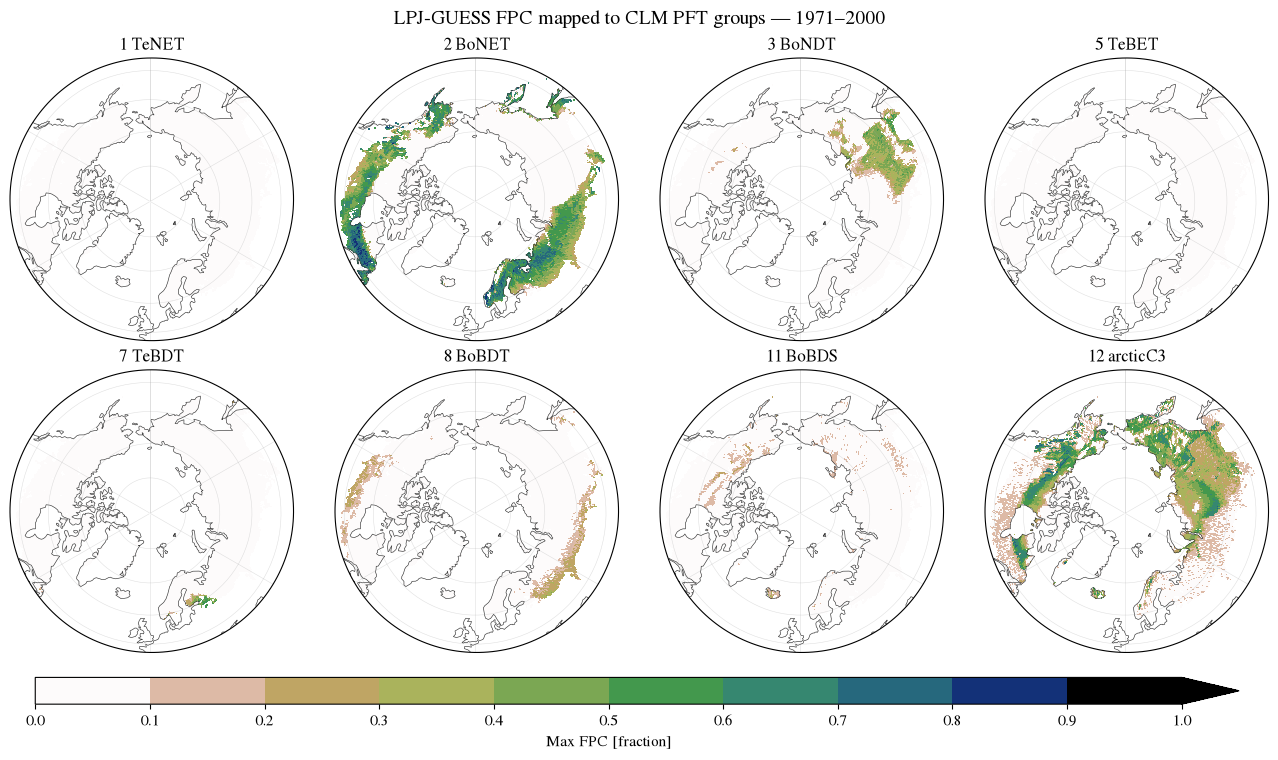

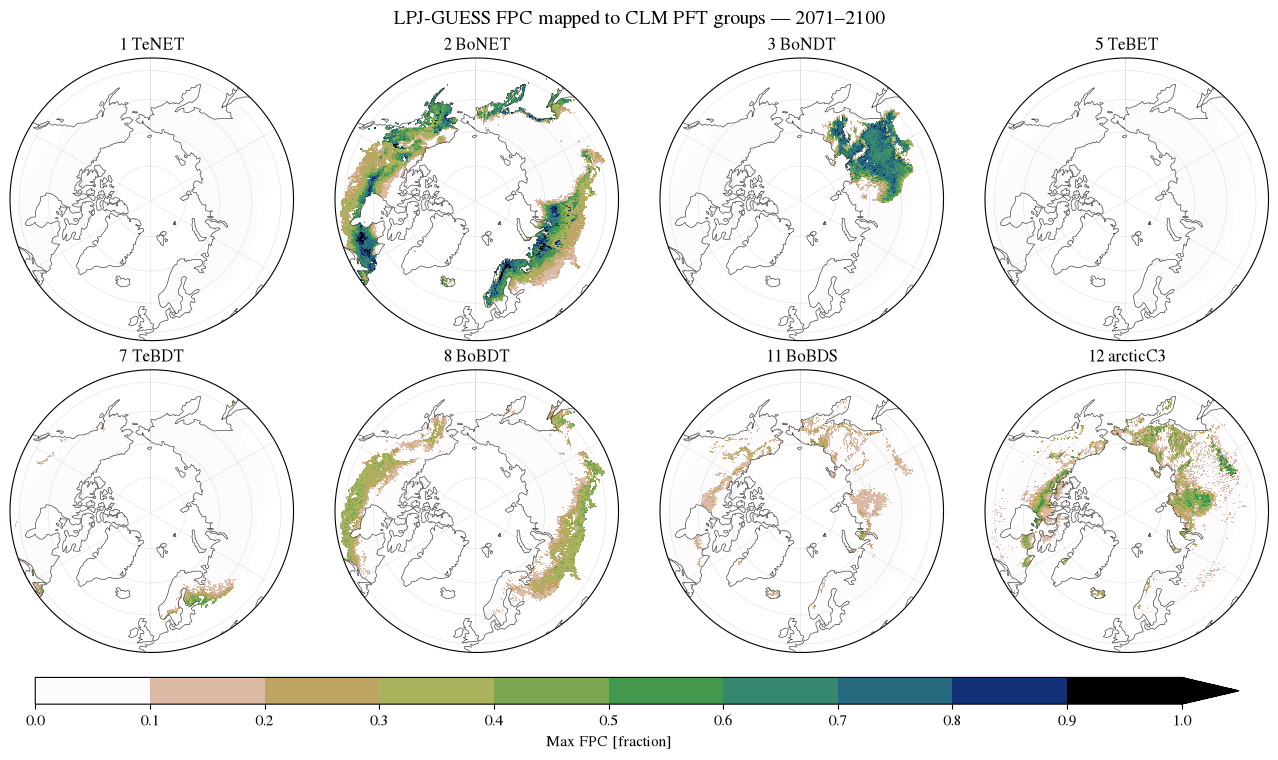

,metric,value
0,valid CLM cells,4914.000000
1,cells with finite anomaly,1309.000000
2,cells with source coverage >= 50%,876.000000
3,cells selected for modification,876.000000
4,minimum retained source coverage,0.501878


In [9]:
pft_titles = [
    f"{pft} {CLM_NAMES[pft]}"
    for pft in PFTS_TO_CHANGE
]

cover_values = np.concatenate([
    historical_src.values[np.isfinite(historical_src.values)],
    future_src.values[np.isfinite(future_src.values)],
])

cover_step = 0.1
cover_upper = 1.0 #max(cover_step,np.ceil(np.percentile(cover_values, 99) / cover_step) * cover_step,)
cover_levels = np.arange(0, cover_upper + cover_step, cover_step)
cover_cmap, cover_norm = discrete_scale(
    "gist_earth_r",
    cover_levels,
    under="white",
    over="black",
)

for period, field, filename in [
    (
        HIST_PERIOD,
        historical_src,
        "historical_max_fpc_clm_groups_native_grid",
    ),
    (
        FUT_PERIOD,
        future_src,
        "future_max_fpc_clm_groups_native_grid",
    ),
]:
    fig = map_panel(
        fields=[
            field.sel(natpft=pft)
            for pft in PFTS_TO_CHANGE
        ],
        panel_titles=pft_titles,
        colorbar_label="Max FPC [fraction]",
        cmap=cover_cmap,
        norm=cover_norm,
        ticks=cover_levels,
        extend="max",
        figure_title=(
            "LPJ-GUESS FPC mapped to CLM PFT groups "
            f"— {period}"
        ),
    )
    save_figure(fig, filename)
    plt.show()
    
src_grid_masked = make_grid(delta_src.lat.values, delta_src.lon.values, source_mask)
src_grid_full = make_grid(delta_src.lat.values, delta_src.lon.values)
dst_grid = make_grid(pct_clm.lat.values, pct_clm.lon.values)

anomaly_regridder = xe.Regridder(
    src_grid_masked, dst_grid, "conservative_normed",
    unmapped_to_nan=True, ignore_degenerate=False,
)
delta_regridded = anomaly_regridder(delta_src, keep_attrs=True, skipna=True, na_thres=1.0)

coverage_regridder = xe.Regridder(
    src_grid_full, dst_grid, "conservative",
    unmapped_to_nan=True, ignore_degenerate=False,
)
source_coverage = coverage_regridder(source_mask.astype(float)).clip(0, 1)
finite_anomaly = np.isfinite(delta_regridded).all("natpft")
adequate_coverage = source_coverage >= MIN_SOURCE_COVERAGE
modify_domain = valid_clm & finite_anomaly & adequate_coverage

if not bool(modify_domain.any()):
    raise ValueError("No CLM cell passes validity and LPJ coverage checks")
missing_inside_domain = delta_regridded.isnull().any("natpft") & modify_domain
if bool(missing_inside_domain.any()):
    raise ValueError(f"Missing anomaly inside modification domain: {int(missing_inside_domain.sum())}")

coverage_summary = pd.DataFrame({
    "metric": [
        "valid CLM cells", "cells with finite anomaly",
        f"cells with source coverage >= {MIN_SOURCE_COVERAGE:.0%}",
        "cells selected for modification", "minimum retained source coverage",
    ],
    "value": [
        int(valid_clm.sum()), int(finite_anomaly.sum()), int(adequate_coverage.sum()),
        int(modify_domain.sum()), float(source_coverage.where(modify_domain).min()),
    ],
})
display(coverage_summary)

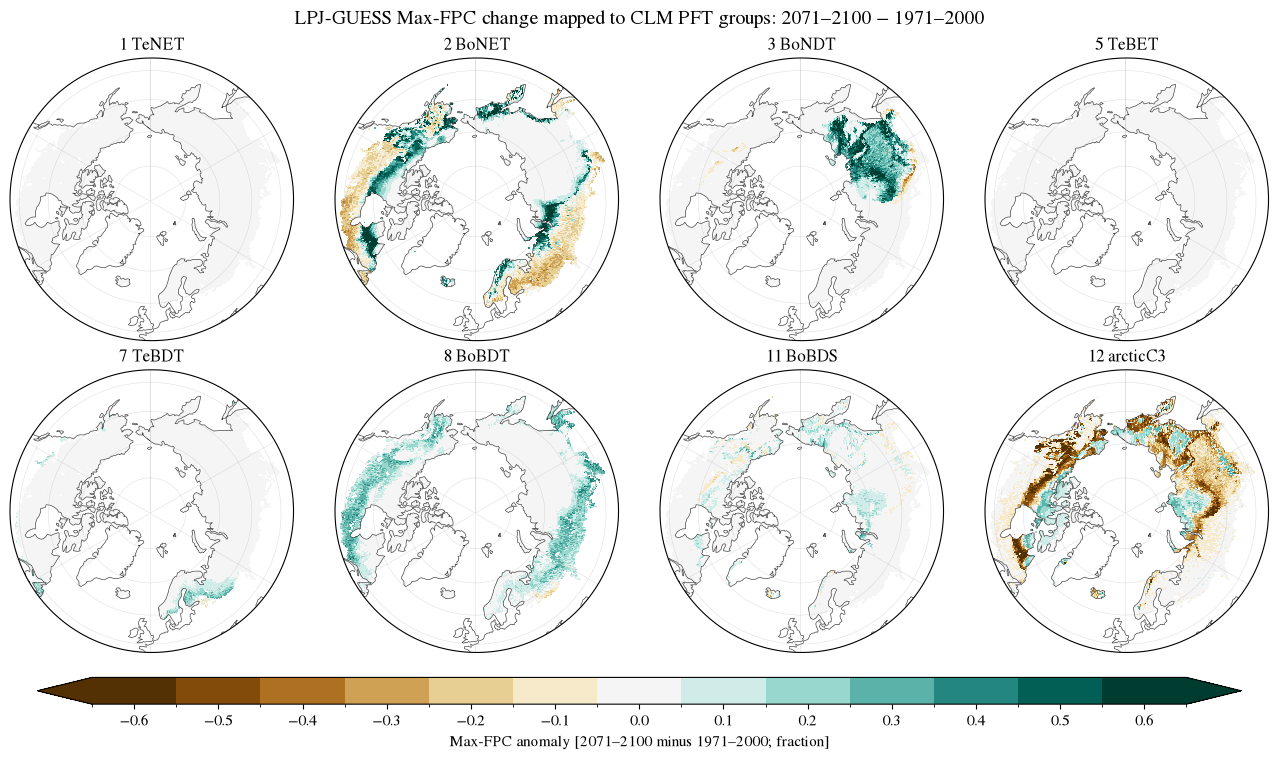

In [10]:
source_abs = np.abs(
    delta_src.values[np.isfinite(delta_src.values)]
)

anomaly_step = 0.1
anomaly_limit = max(
    anomaly_step,
    np.ceil(np.percentile(source_abs, 99) / anomaly_step) * anomaly_step,
)

anomaly_levels = np.arange(
    -anomaly_limit - anomaly_step / 2,
    anomaly_limit + anomaly_step,
    anomaly_step,
)
anomaly_ticks = np.arange(
    -anomaly_limit,
    anomaly_limit + anomaly_step,
    anomaly_step,
)

anomaly_cmap, anomaly_norm = discrete_scale(
    "BrBG",
    anomaly_levels,
)

fig = map_panel(
    fields=[
        delta_src.sel(natpft=pft)
        for pft in PFTS_TO_CHANGE
    ],
    panel_titles=pft_titles,
    colorbar_label=(
        f"Max-FPC anomaly "
        f"[{FUT_PERIOD} minus {HIST_PERIOD}; fraction]"
    ),
    cmap=anomaly_cmap,
    norm=anomaly_norm,
    ticks=anomaly_ticks,
    extend="both",
    figure_title=(
        "LPJ-GUESS Max-FPC change mapped to CLM PFT groups: "
        f"{FUT_PERIOD} − {HIST_PERIOD}"
    ),
)

save_figure(fig, "max_fpc_anomaly_clm_groups_native_grid")
plt.show()

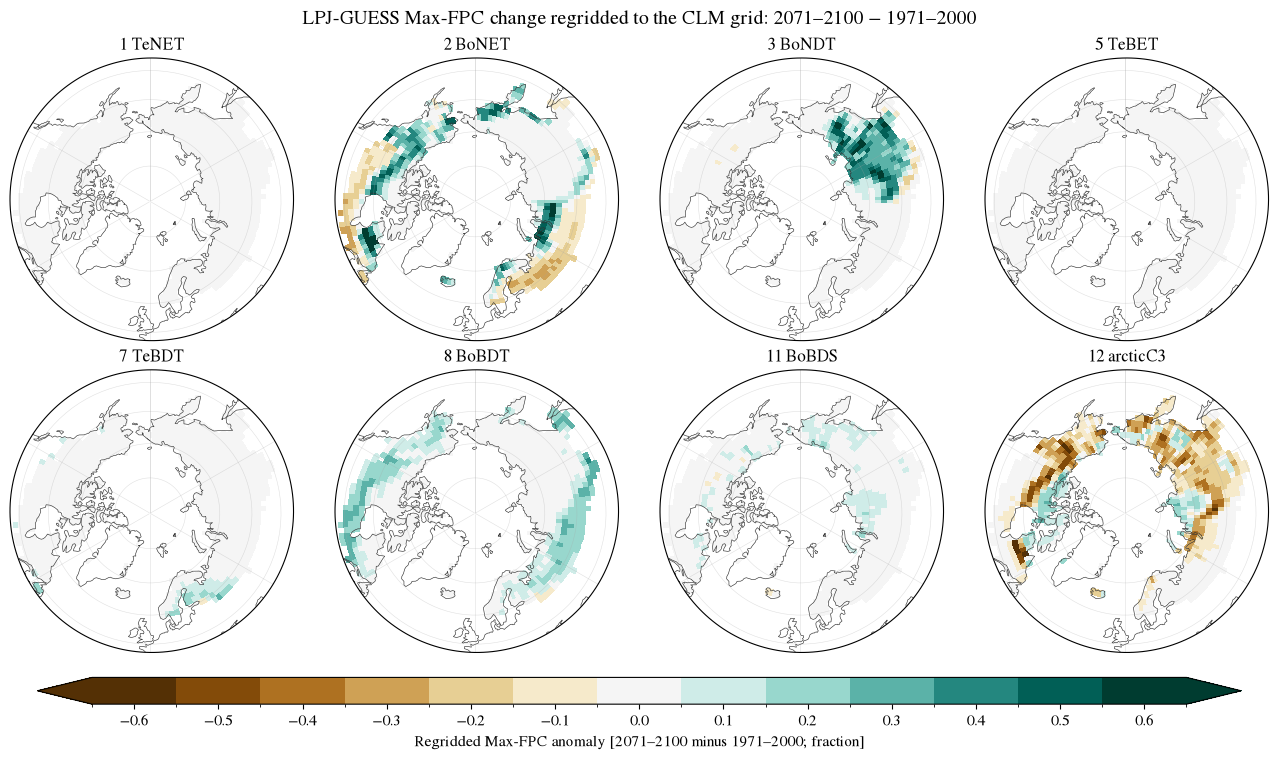

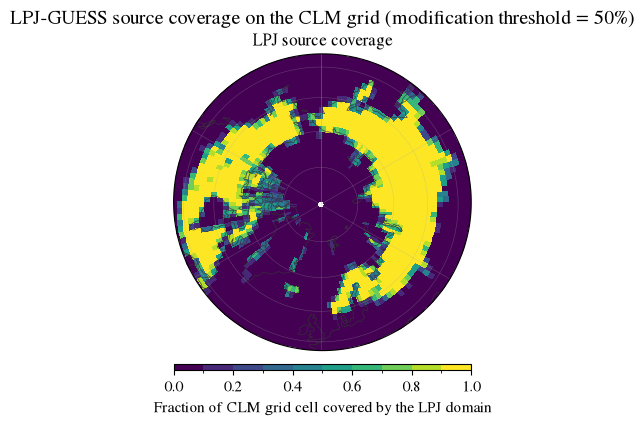

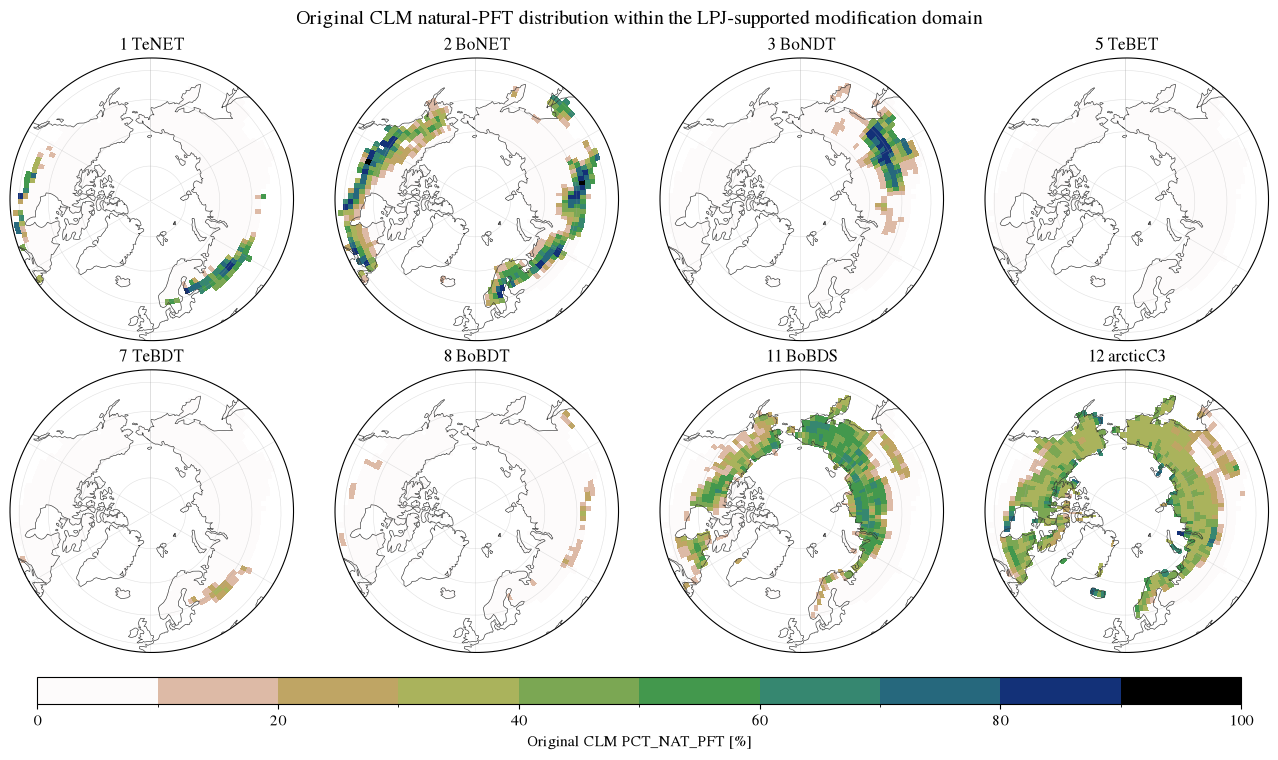

In [11]:
# ------------------------------------------------------------------
# Regridded Max-FPC anomaly
# Reuse anomaly_cmap, anomaly_norm and anomaly_ticks from the
# native-grid anomaly plot.
# ------------------------------------------------------------------

fig = map_panel(
    fields=[
        delta_regridded.sel(natpft=pft).where(modify_domain)
        for pft in PFTS_TO_CHANGE
    ],
    panel_titles=pft_titles,
    colorbar_label=(
        f"Regridded Max-FPC anomaly "
        f"[{FUT_PERIOD} minus {HIST_PERIOD}; fraction]"
    ),
    cmap=anomaly_cmap,
    norm=anomaly_norm,
    ticks=anomaly_ticks,
    extend="both",
    figure_title=(
        "LPJ-GUESS Max-FPC change regridded to the CLM grid: "
        f"{FUT_PERIOD} − {HIST_PERIOD}"
    ),
)

save_figure(fig, "max_fpc_anomaly_regridded_to_clm")
plt.show()


# ------------------------------------------------------------------
# LPJ source coverage on the CLM grid
# ------------------------------------------------------------------

coverage_levels = np.arange(0, 1.01, 0.1)
coverage_ticks = np.arange(0, 1.01, 0.2)
coverage_cmap, coverage_norm = discrete_scale(
    "viridis",
    coverage_levels,
)

fig = map_panel(
    fields=[source_coverage],
    panel_titles=["LPJ source coverage"],
    colorbar_label="Fraction of CLM grid cell covered by the LPJ domain",
    cmap=coverage_cmap,
    norm=coverage_norm,
    ticks=coverage_ticks,
    extend="neither",
    figure_title=(
        "LPJ-GUESS source coverage on the CLM grid "
        f"(modification threshold = {MIN_SOURCE_COVERAGE:.0%})"
    ),
    ncols=1,
)

save_figure(fig, "lpj_source_coverage_on_clm_grid")
plt.show()


# ------------------------------------------------------------------
# Original CLM PFT distribution inside the modification domain
# ------------------------------------------------------------------

clm_levels = np.arange(0, 101, 10)
clm_ticks = np.arange(0, 101, 20)
clm_cmap, clm_norm = discrete_scale(
    "gist_earth_r",
    clm_levels,
    under="white",
    over="black",
)

fig = map_panel(
    fields=[
        pct_clm.sel(natpft=pft).where(modify_domain)
        for pft in PFTS_TO_CHANGE
    ],
    panel_titles=pft_titles,
    colorbar_label="Original CLM PCT_NAT_PFT [%]",
    cmap=clm_cmap,
    norm=clm_norm,
    ticks=clm_ticks,
    extend="neither",
    figure_title=(
        "Original CLM natural-PFT distribution "
        "within the LPJ-supported modification domain"
    ),
)

save_figure(
    fig,
    "original_clm_pct_nat_pft_in_modification_domain",
)
plt.show()

## 7. Apply losses first and constrain gains

In [12]:
delta_requested = 100 * delta_regridded.sel(natpft=PFTS_TO_CHANGE)
base_changed = pct_clm.sel(natpft=PFTS_TO_CHANGE)
untouched = [
    int(pft) for pft in pct_clm.natpft.values
    if int(pft) not in PFTS_TO_CHANGE and int(pft) != BARE
]
untouched_sum = pct_clm.sel(natpft=untouched).sum("natpft")
block_total = 100 - untouched_sum
if float(block_total.where(valid_clm).min()) < -1e-8:
    raise ValueError("Untouched CLM PFTs exceed 100% in at least one valid cell")

requested_loss = xr.where(delta_requested < 0, delta_requested, 0)
requested_gain = xr.where(delta_requested > 0, delta_requested, 0)
after_loss = (base_changed + requested_loss).clip(min=0)
realised_loss = after_loss - base_changed

raw_gain_capacity = block_total - after_loss.sum("natpft")
if float(raw_gain_capacity.where(valid_clm).min()) < -1e-8:
    raise ValueError("Negative gain capacity before clipping; inspect the CLM baseline")
gain_capacity = raw_gain_capacity.clip(min=0)
requested_gain_sum = requested_gain.sum("natpft")
gain_scale = xr.where(
    requested_gain_sum > 0,
    np.minimum(1.0, gain_capacity / requested_gain_sum),
    1.0,
)

new_changed = after_loss + requested_gain * gain_scale
new_bare = block_total - new_changed.sum("natpft")
pct_new = pct_clm.copy(deep=True)
pct_new.loc[dict(natpft=PFTS_TO_CHANGE)] = new_changed
pct_new.loc[dict(natpft=BARE)] = new_bare
pct_new = pct_new.where(modify_domain, pct_clm)
pct_new.name = pct_clm.name
pct_new.attrs = pct_clm.attrs.copy()

realised_delta = (pct_new - pct_clm).sel(natpft=PFTS_TO_CHANGE)
adjustment = realised_delta - delta_requested
loss_clipped = (requested_loss < realised_loss - 1e-10).any("natpft") & modify_domain
gain_scaled = (gain_scale < 1 - 1e-10) & modify_domain
zero_capacity = (requested_gain_sum > 1e-10) & (gain_capacity <= 1e-10) & modify_domain

constraint_summary = pd.DataFrame({
    "metric": [
        "cells with a clipped loss", "cells with scaled gains",
        "gain cells with zero capacity", "minimum gain scale",
    ],
    "value": [
        int(loss_clipped.sum()), int(gain_scaled.sum()), int(zero_capacity.sum()),
        float(gain_scale.where(modify_domain).min()),
    ],
})
display(constraint_summary)

,metric,value
0,cells with a clipped loss,340.0
1,cells with scaled gains,712.0
2,gain cells with zero capacity,14.0
3,minimum gain scale,0.0


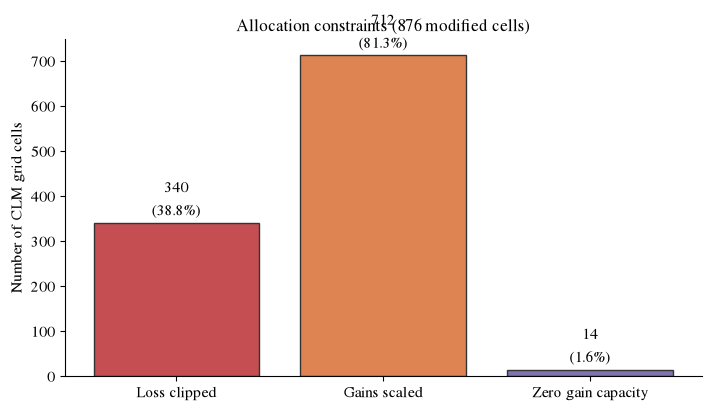

In [13]:
from matplotlib.colors import BoundaryNorm, ListedColormap

n_modified = int(modify_domain.sum())
diagnostics = [
    ("Loss clipped", loss_clipped, "#C44E52"),
    ("Gains scaled", gain_scaled, "#DD8452"),
    ("Zero gain capacity", zero_capacity, "#8172B2"),
]

# Count summary
counts = np.array([int(field.sum()) for _, field, _ in diagnostics])
percentages = 100 * counts / n_modified

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
bars = ax.bar(
    [label for label, _, _ in diagnostics],
    counts,
    color=[color for _, _, color in diagnostics],
    edgecolor="0.2",
)

for bar, count, percentage in zip(bars, counts, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
    )

ax.set(
    ylabel="Number of CLM grid cells",
    title=f"Allocation constraints ({n_modified:,} modified cells)",
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "allocation_constraint_counts")
plt.show()

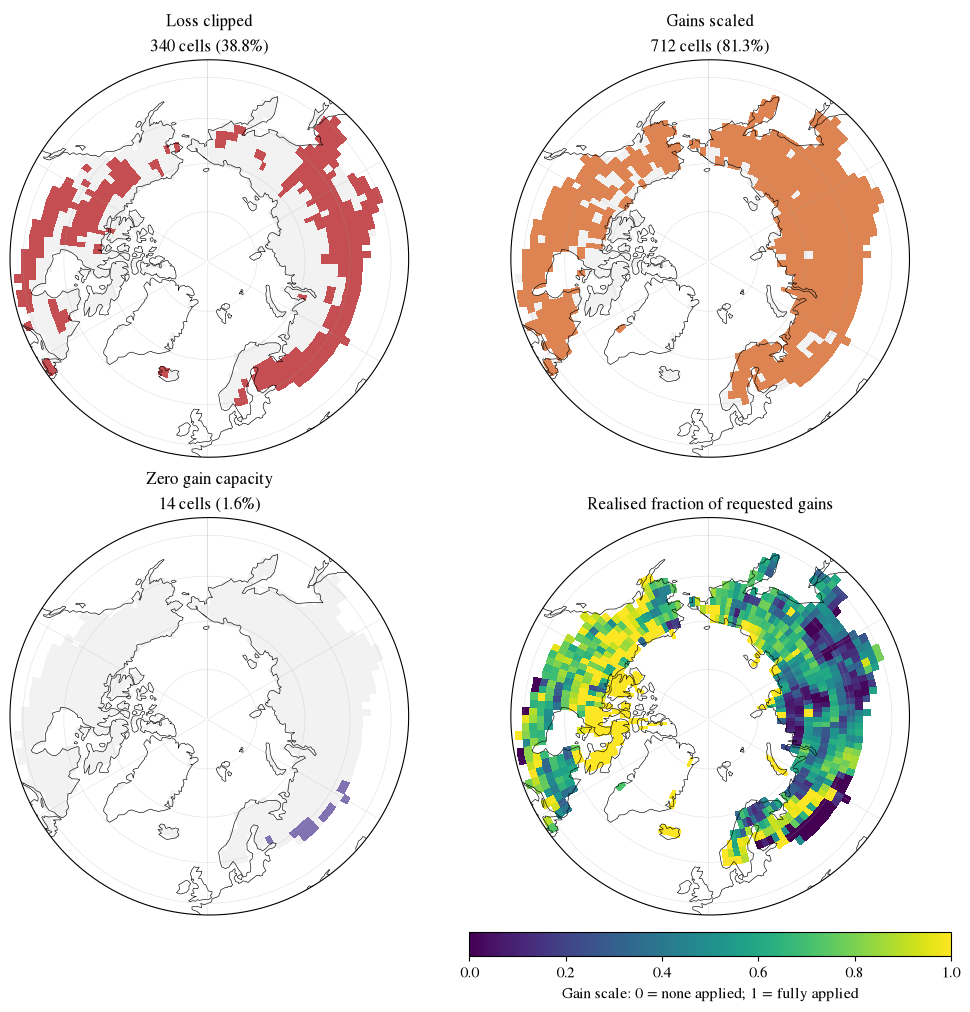

In [14]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
    layout="constrained",
)
axes = axes.ravel()

binary_norm = BoundaryNorm([-0.5, 0.5, 1.5], 2)

for ax, (label, field, color) in zip(axes[:3], diagnostics):
    count = int(field.sum())
    percentage = 100 * count / n_modified
    cmap = ListedColormap(["#F2F2F2", color])

    field.astype(float).where(modify_domain).plot.pcolormesh(
        ax=ax,
        x="lon",
        y="lat",
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=binary_norm,
        add_colorbar=False,
    )

    ax.set_title(f"{label}\n{count:,} cells ({percentage:.1f}%)")
    ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
    circular_boundary(ax)
    ax.coastlines(linewidth=0.45)
    ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)

# Show gain scale only where a positive gain was requested
gain_cells = (requested_gain_sum > 0) & modify_domain
image = gain_scale.where(gain_cells).plot.pcolormesh(
    ax=axes[3],
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=0,
    vmax=1,
    add_colorbar=False,
)

axes[3].set_title("Realised fraction of requested gains")
axes[3].set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
circular_boundary(axes[3])
axes[3].coastlines(linewidth=0.45)
axes[3].gridlines(linewidth=0.4, color="0.65", alpha=0.35)

colorbar = fig.colorbar(image, ax=axes[3], orientation="horizontal", pad=0.04)
colorbar.set_label("Gain scale: 0 = none applied; 1 = fully applied")

save_figure(fig, "allocation_constraints_spatial")
plt.show()

## 8. Validate and summarize requested versus realised changes

In [15]:
def spherical_cell_area(lat, lon, radius=6_371_000.0):
    lat_b = np.deg2rad(np.clip(bounds_1d(lat), -90, 90))
    lon_b = np.deg2rad(bounds_1d(lon))
    values = radius**2 * np.diff(np.sin(lat_b))[:, None] * np.diff(lon_b)[None, :]
    return xr.DataArray(values, coords={"lat": lat, "lon": lon}, dims=("lat", "lon"))


def weighted_mean(field, weights, mask):
    usable = mask & np.isfinite(field) & np.isfinite(weights) & (weights > 0)
    denominator = weights.where(usable).sum()
    return float((field.where(usable) * weights.where(usable)).sum() / denominator)

partition_error = np.abs(pct_new.sum("natpft", skipna=False) - 100).where(valid_clm)
assert float(partition_error.max(skipna=True)) < 1e-8
assert float(pct_new.where(valid_clm).min(skipna=True)) >= -1e-8
assert float(pct_new.where(valid_clm).max(skipna=True)) <= 100 + 1e-8
xr.testing.assert_identical(pct_new.sel(natpft=untouched), pct_clm.sel(natpft=untouched))
xr.testing.assert_identical(pct_new.where(~modify_domain), pct_clm.where(~modify_domain))

weights = spherical_cell_area(pct_clm.lat.values, pct_clm.lon.values) * landfrac * natveg / 100
rows = []
for pft in PFTS_TO_CHANGE:
    requested = delta_requested.sel(natpft=pft)
    realised = realised_delta.sel(natpft=pft)
    rows.append({
        "clm_natpft": pft, "clm_abbrev": CLM_NAMES[pft],
        "requested_mean_pp": weighted_mean(requested, weights, modify_domain),
        "realised_mean_pp": weighted_mean(realised, weights, modify_domain),
        "mean_adjustment_pp": weighted_mean(realised - requested, weights, modify_domain),
        "max_abs_adjustment_pp": float(np.abs(realised - requested).where(modify_domain).max()),
    })

bare_delta = (pct_new - pct_clm).sel(natpft=BARE)
rows.append({
    "clm_natpft": BARE, "clm_abbrev": "BG", "requested_mean_pp": np.nan,
    "realised_mean_pp": weighted_mean(bare_delta, weights, modify_domain),
    "mean_adjustment_pp": np.nan, "max_abs_adjustment_pp": np.nan,
})
change_summary = pd.DataFrame(rows).sort_values("clm_natpft")
display(change_summary.round(4))
print(f"Worst |PFT sum - 100|: {float(partition_error.max()):.3e}")

source_qc.to_csv(TABLE_DIR / "source_qc.csv", index=False)
coverage_summary.to_csv(TABLE_DIR / "target_coverage_qc.csv", index=False)
constraint_summary.to_csv(TABLE_DIR / "allocation_constraints.csv", index=False)
change_summary.to_csv(TABLE_DIR / "requested_vs_realised_change.csv", index=False)

,clm_natpft,clm_abbrev,requested_mean_pp,realised_mean_pp,mean_adjustment_pp,max_abs_adjustment_pp
8,0,BG,NaN,-3.0149,NaN,NaN
0,1,TeNET,0.0006,0.0005,-0.0001,0.0733
1,2,BoNET,4.0668,2.1563,-1.9106,37.2144
2,3,BoNDT,7.5642,3.6361,-3.9280,29.6295
3,5,TeBET,0.0001,0.0001,-0.0000,0.0003
4,7,TeBDT,0.9010,0.4628,-0.4382,25.5878
5,8,BoBDT,8.2734,4.9820,-3.2914,32.5536
6,11,BoBDS,1.2252,0.6443,-0.5809,13.3072
7,12,arcticC3,-10.3293,-8.8672,1.4621,23.6557


Worst |PFT sum - 100|: 9.948e-14


## 9. Plot requested, realised, adjustment, and final distributions

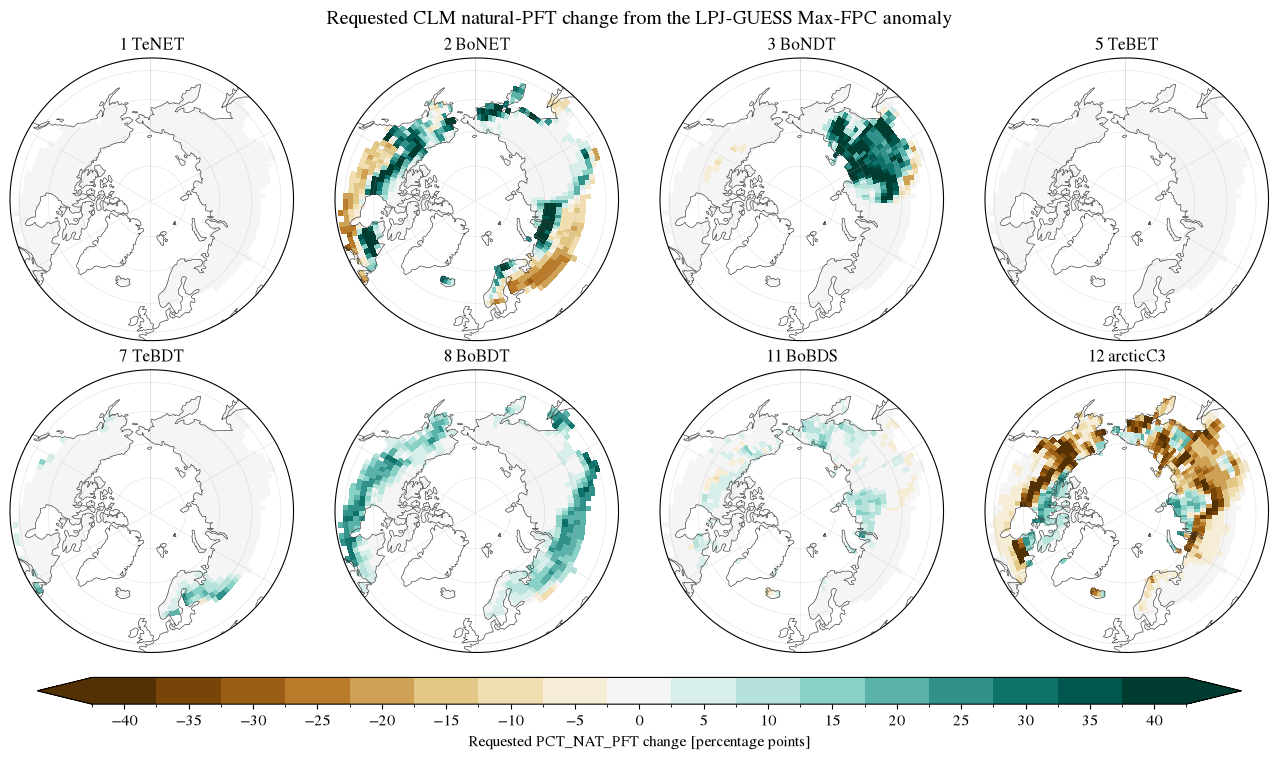

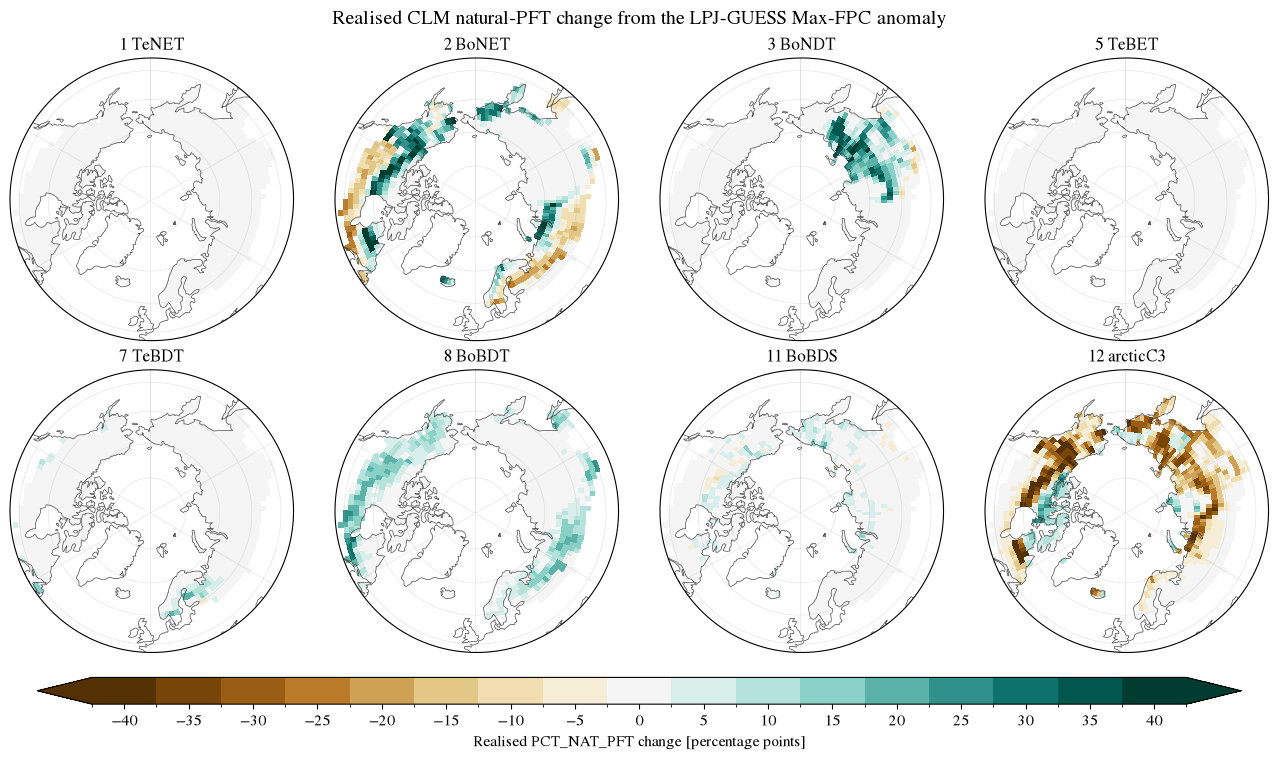

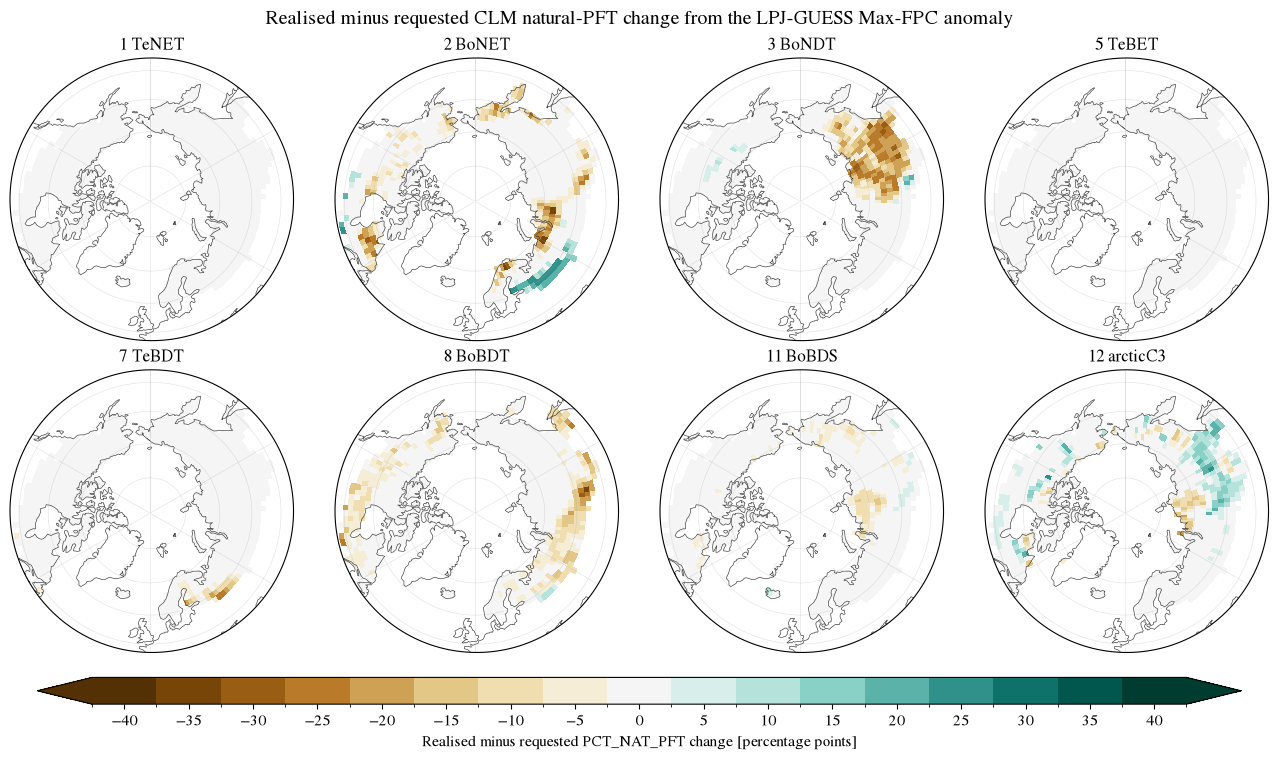

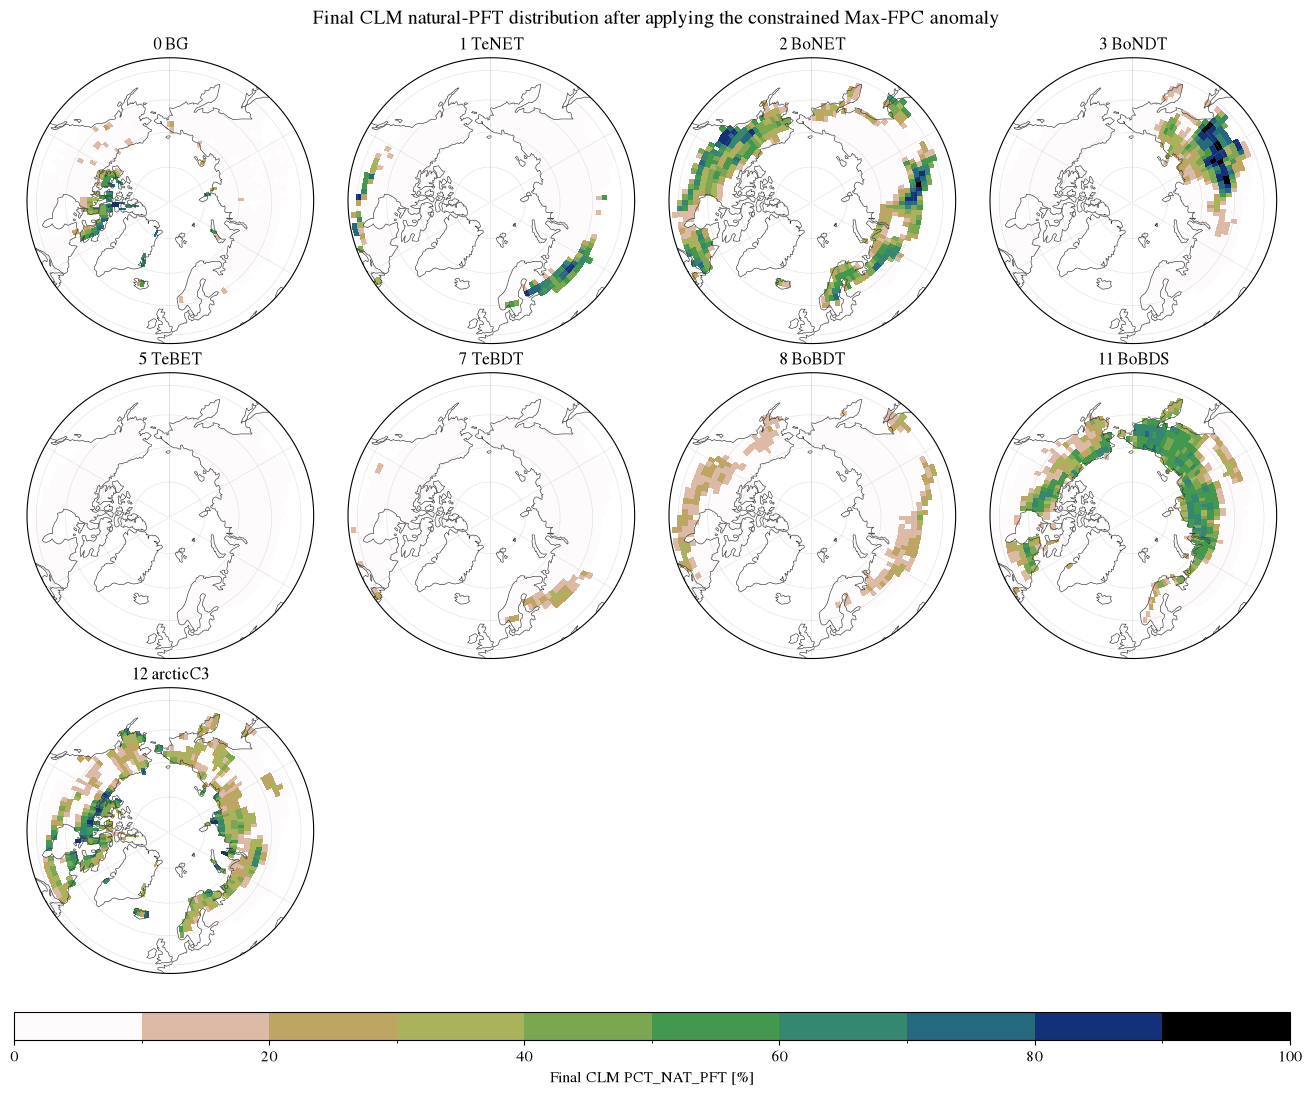

In [16]:
# Use one discrete scale for all requested, realised and adjustment maps.
change_arrays = [
    delta_requested.where(modify_domain),
    realised_delta.where(modify_domain),
    adjustment.where(modify_domain),
]

finite_changes = np.concatenate([
    np.abs(array.values[np.isfinite(array.values)])
    for array in change_arrays
])

change_step = 5.0
change_limit = max(
    change_step,
    np.ceil(np.percentile(finite_changes, 99) / change_step) * change_step,
)

# Offset boundaries by half a step so the central interval is centred on zero.
change_levels = np.arange(
    -change_limit - change_step / 2,
    change_limit + change_step,
    change_step,
)
change_ticks = np.arange(
    -change_limit,
    change_limit + change_step,
    change_step,
)

change_cmap, change_norm = discrete_scale(
    "BrBG",
    change_levels,
)


for label, field, filename in [
    (
        "Requested",
        delta_requested,
        "requested_pct_nat_pft_change",
    ),
    (
        "Realised",
        realised_delta,
        "realised_pct_nat_pft_change",
    ),
    (
        "Realised minus requested",
        adjustment,
        "constraint_adjustment",
    ),
]:
    fig = map_panel(
        fields=[
            field.sel(natpft=pft).where(modify_domain)
            for pft in PFTS_TO_CHANGE
        ],
        panel_titles=pft_titles,
        colorbar_label=(
            f"{label} PCT_NAT_PFT change "
            "[percentage points]"
        ),
        cmap=change_cmap,
        norm=change_norm,
        ticks=change_ticks,
        extend="both",
        figure_title=(
            f"{label} CLM natural-PFT change from the "
            "LPJ-GUESS Max-FPC anomaly"
        ),
    )

    save_figure(fig, filename)
    plt.show()


# Final PCT_NAT_PFT distribution
final_pfts = [BARE, *PFTS_TO_CHANGE]
final_titles = [
    f"{pft} {CLM_NAMES.get(pft, str(pft))}"
    for pft in final_pfts
]

final_levels = np.arange(0, 101, 10)
final_ticks = np.arange(0, 101, 20)
final_cmap, final_norm = discrete_scale(
    "gist_earth_r",
    final_levels,
    under="white",
    over="black",
)

fig = map_panel(
    fields=[
        pct_new.sel(natpft=pft).where(modify_domain)
        for pft in final_pfts
    ],
    panel_titles=final_titles,
    colorbar_label="Final CLM PCT_NAT_PFT [%]",
    cmap=final_cmap,
    norm=final_norm,
    ticks=final_ticks,
    extend="neither",
    figure_title=(
        "Final CLM natural-PFT distribution after applying "
        "the constrained Max-FPC anomaly"
    ),
)

save_figure(fig, "final_clm_pct_nat_pft")
plt.show()

## Check on COVERAGE THRESHOLD

,natpft,realised_area_change_km2
0,1,107.6
1,2,451779.8
2,3,761842.5
3,5,31.0
4,7,96960.7
5,8,1043815.6
6,11,134993.2
7,12,-1857843.9


modified cells        876.00
loss clipped [%]       38.81
gains scaled [%]       81.28
zero capacity [%]       1.60
minimum gain scale      0.00
dtype: float64

,coverage class,CLM cells
0,25–<50%,157
1,50–<75%,157
2,75–<90%,94
3,≥90%,625


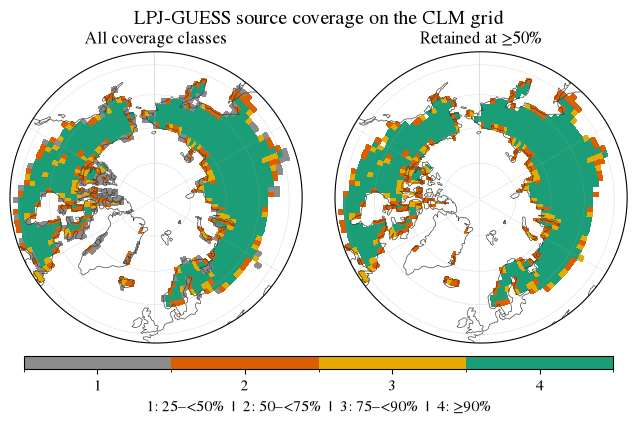

In [17]:
# 2. Requested and realised changes by PFT
requested_mean = change_summary["requested_mean_pp"]

change_summary["fraction_realised"] = np.where(
    requested_mean.abs() > 1e-12,
    change_summary["realised_mean_pp"] / requested_mean,
    np.nan,
)

# 3. Physical-area changes
cell_area = spherical_cell_area(pct_clm.lat.values, pct_clm.lon.values)

# Physical area of the CLM natural-vegetation land unit [m²].
physical_weight = cell_area * landfrac * natveg / 100
weights = physical_weight

equivalent_area_change = (
    realised_delta.where(modify_domain)
    * physical_weight.where(modify_domain)
    / 100
).sum(("lat", "lon"), skipna=True) / 1e6  # km²

area_change_table = equivalent_area_change.to_dataframe(
    name="realised_area_change_km2"
).reset_index()

display(area_change_table.round(1))

# 4. Constraint frequency
n_modified = int(modify_domain.sum().item())
if n_modified == 0:
    raise ValueError("No CLM cells satisfy the modification criteria")

def count_in_domain(field):
    return int(field.where(modify_domain, False).sum().item())

n_loss_clipped = count_in_domain(loss_clipped)
n_gain_scaled = count_in_domain(gain_scaled)
n_zero_capacity = count_in_domain(zero_capacity)

constraint_comparison = pd.Series({
    "modified cells": n_modified,
    "loss clipped [%]": 100 * n_loss_clipped / n_modified,
    "gains scaled [%]": 100 * n_gain_scaled / n_modified,
    "zero capacity [%]": 100 * n_zero_capacity / n_modified,
    "minimum gain scale": float(
        gain_scale.where(modify_domain).min(skipna=True).item()
    ),
})

display(constraint_comparison.round(2))

# 5. Source-coverage sensitivity
finite_anomaly = np.isfinite(
    delta_regridded.sel(natpft=PFTS_TO_CHANGE)
).all("natpft")

coverage_domain = valid_clm & finite_anomaly
coverage_band = xr.full_like(source_coverage, np.nan, dtype=float)

coverage_band = xr.where(
    coverage_domain & (source_coverage >= 0.25) & (source_coverage < 0.50),
    1,
    coverage_band,
)
coverage_band = xr.where(
    coverage_domain & (source_coverage >= 0.50) & (source_coverage < 0.75),
    2,
    coverage_band,
)
coverage_band = xr.where(
    coverage_domain & (source_coverage >= 0.75) & (source_coverage < 0.90),
    3,
    coverage_band,
)
coverage_band = xr.where(
    coverage_domain & (source_coverage >= 0.90),
    4,
    coverage_band,
)

coverage_labels = {
    1: "25–<50%",
    2: "50–<75%",
    3: "75–<90%",
    4: "≥90%",
}

coverage_counts = pd.DataFrame({
    "coverage class": list(coverage_labels.values()),
    "CLM cells": [
        int((coverage_band == code).sum().item())
        for code in coverage_labels
    ],
})

display(coverage_counts)

coverage_cmap = mcolors.ListedColormap([
    "#8C8C8C",  # 25–<50%
    "#D95F02",  # 50–<75%
    "#E6AB02",  # 75–<90%
    "#1B9E77",  # >=90%
])
coverage_norm = mcolors.BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5, 4.5],
    coverage_cmap.N,
)

fig = map_panel(
    fields=[
        coverage_band,
        coverage_band.where(modify_domain),
    ],
    panel_titles=[
        "All coverage classes",
        f"Retained at ≥{MIN_SOURCE_COVERAGE:.0%}",
    ],
    colorbar_label=(
        "1: 25–<50%  |  2: 50–<75%  |  "
        "3: 75–<90%  |  4: ≥90%"
    ),
    cmap=coverage_cmap,
    norm=coverage_norm,
    ticks=[1, 2, 3, 4],
    extend="neither",
    figure_title="LPJ-GUESS source coverage on the CLM grid",
    ncols=2,
)

plt.show()

In [19]:
bare_area_change = (
    bare_delta.where(modify_domain)
    * physical_weight.where(modify_domain)
    / 100
).sum(("lat", "lon"), skipna=True).item() / 1e6

mapped_area_change = equivalent_area_change.sum("natpft").item()
area_closure_error = mapped_area_change + bare_area_change

area_budget = pd.Series({
    "mapped PFT change [km²]": mapped_area_change,
    "bare-ground change [km²]": bare_area_change,
    "closure residual [km²]": area_closure_error,
})

display(area_budget.round(1))
assert abs(area_closure_error) < 1e-3

mapped PFT change [km²]     631686.4
bare-ground change [km²]   -631686.4
closure residual [km²]           0.0
dtype: float64

In [20]:
coverage_area = []

for code, label in coverage_labels.items():
    mask = coverage_band == code
    area_km2 = physical_weight.where(mask).sum(skipna=True).item() / 1e6

    coverage_area.append({
        "coverage class": label,
        "CLM cells": int(mask.sum().item()),
        "natural-vegetation area [km²]": area_km2,
    })

coverage_area = pd.DataFrame(coverage_area)
coverage_area["area share [%]"] = (
    100
    * coverage_area["natural-vegetation area [km²]"]
    / coverage_area["natural-vegetation area [km²]"].sum()
)

display(coverage_area.round({
    "natural-vegetation area [km²]": 0,
    "area share [%]": 1,
}))

,coverage class,CLM cells,natural-vegetation area [km²],area share [%]
0,25–<50%,157,2247234.0,9.7
1,50–<75%,157,3104858.0,13.4
2,75–<90%,94,2070597.0,8.9
3,≥90%,625,15776491.0,68.0


In [21]:
# Approximate fraction of the CLM land area supported by LPJ-GUESS.
land_relative_coverage = xr.where(
    landfrac > 0,
    (source_coverage / landfrac).clip(min=0, max=1),
    np.nan,
)

# Retain:
# 1. every cell with at least 50% total-cell coverage; or
# 2. coastal cells with 25–50% total-cell coverage when LPJ-GUESS
#    covers at least 80% of the CLM land fraction.
coastal_extension = (
    (source_coverage >= 0.25)
    & (source_coverage < 0.50)
    & (land_relative_coverage >= 0.80)
)

adequate_coverage = (source_coverage >= 0.50) | coastal_extension

modify_domain = (
    valid_clm
    & finite_anomaly
    & adequate_coverage
).fillna(False)

coverage_diagnostics = pd.Series({
    "standard cells with coverage >=50%":
        int((coverage_domain & (source_coverage >= 0.50)).sum().item()),
    "additional coastal cells":
        int((coverage_domain & coastal_extension).sum().item()),
    "total modified cells":
        int(modify_domain.sum().item()),
    "minimum total-cell coverage":
        float(source_coverage.where(modify_domain).min(skipna=True).item()),
    "minimum land-relative coverage":
        float(land_relative_coverage.where(modify_domain).min(skipna=True).item()),
})

display(coverage_diagnostics.round(3))

standard cells with coverage >=50%    876.000
additional coastal cells               15.000
total modified cells                  891.000
minimum total-cell coverage             0.264
minimum land-relative coverage          0.511
dtype: float64

In [22]:
standard_domain = coverage_domain & (source_coverage >= 0.50)
coastal_domain = coverage_domain & coastal_extension

standard_area = physical_weight.where(standard_domain).sum(skipna=True).item() / 1e6
coastal_area = physical_weight.where(coastal_domain).sum(skipna=True).item() / 1e6
total_area = physical_weight.where(modify_domain).sum(skipna=True).item() / 1e6

coverage_diagnostics = pd.Series({
    "standard cells": int(standard_domain.sum().item()),
    "additional coastal cells": int(coastal_domain.sum().item()),
    "total modified cells": int(modify_domain.sum().item()),
    "additional coastal area [km²]": coastal_area,
    "coastal share of modified area [%]": 100 * coastal_area / total_area,
    "minimum coverage in coastal extension":
        float(source_coverage.where(coastal_domain).min(skipna=True).item()),
    "minimum land-relative coverage in coastal extension":
        float(land_relative_coverage.where(coastal_domain).min(skipna=True).item()),
})

display(coverage_diagnostics.round(3))

standard cells                                            876.000
additional coastal cells                                   15.000
total modified cells                                      891.000
additional coastal area [km²]                          162723.338
coastal share of modified area [%]                          0.771
minimum coverage in coastal extension                       0.264
minimum land-relative coverage in coastal extension         0.804
dtype: float64

,lat,lon,source_coverage,CLM_land_fraction,land_relative_coverage,natural_vegetation_area_km2
0,50.211,-60.0,0.451,0.516,0.873,17615.1
1,54.000,140.0,0.476,0.582,0.819,19087.5
2,55.895,155.0,0.264,0.264,1.000,8673.8
3,55.895,162.5,0.475,0.544,0.873,17693.0
4,69.158,-180.0,0.478,0.570,0.838,11879.5
5,69.158,-165.0,0.383,0.439,0.873,9144.1
6,69.158,-137.5,0.452,0.531,0.851,10955.2
7,71.053,-160.0,0.295,0.362,0.815,6271.2
8,71.053,-155.0,0.482,0.588,0.820,9389.1
9,71.053,-122.5,0.413,0.451,0.914,8585.6


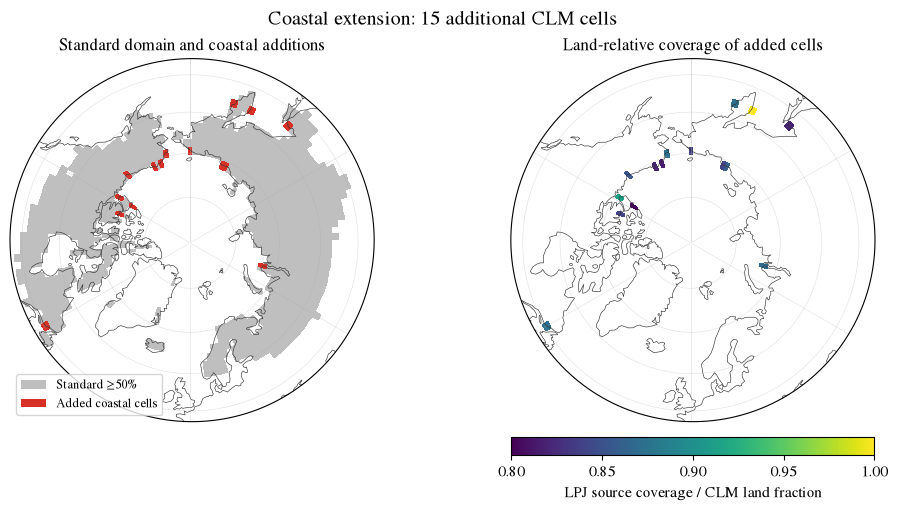

In [23]:
from matplotlib.patches import Patch

# Table of the additional coastal cells
coastal_cells = xr.Dataset({
    "source_coverage": source_coverage,
    "CLM_land_fraction": landfrac,
    "land_relative_coverage": land_relative_coverage,
    "natural_vegetation_area_km2": physical_weight / 1e6,
}).where(coastal_domain).to_dataframe().dropna(
    subset=["source_coverage"]
).reset_index()

display(
    coastal_cells.sort_values(["lat", "lon"]).round({
        "lat": 3,
        "lon": 3,
        "source_coverage": 3,
        "CLM_land_fraction": 3,
        "land_relative_coverage": 3,
        "natural_vegetation_area_km2": 1,
    })
)

# Maps
fig, axes = plt.subplots(
    1, 2, figsize=(10, 5),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
    layout="constrained",
)

for ax in axes:
    ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
    circular_boundary(ax)
    ax.coastlines(resolution="110m", linewidth=0.45, color="0.2")
    ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)

# Panel 1: standard domain and coastal additions
xr.where(standard_domain, 1.0, np.nan).plot.pcolormesh(
    ax=axes[0],
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=mcolors.ListedColormap(["0.75"]),
    add_colorbar=False,
)

xr.where(coastal_domain, 1.0, np.nan).plot.pcolormesh(
    ax=axes[0],
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=mcolors.ListedColormap(["#D73027"]),
    add_colorbar=False,
)

axes[0].set_title("Standard domain and coastal additions")
axes[0].legend(
    handles=[
        Patch(facecolor="0.75", label="Standard ≥50%"),
        Patch(facecolor="#D73027", label="Added coastal cells"),
    ],
    loc="lower left",
    frameon=True,
    fontsize=9,
)

# Panel 2: land-relative coverage of the added cells
image = land_relative_coverage.where(coastal_domain).plot.pcolormesh(
    ax=axes[1],
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    norm=mcolors.Normalize(0.80, 1.00),
    add_colorbar=False,
)

axes[1].set_title("Land-relative coverage of added cells")

colorbar = fig.colorbar(
    image,
    ax=axes[1],
    orientation="horizontal",
    fraction=0.05,
    pad=0.04,
    ticks=[0.80, 0.85, 0.90, 0.95, 1.00],
)
colorbar.set_label("LPJ source coverage / CLM land fraction")

fig.suptitle(
    f"Coastal extension: {int(coastal_domain.sum().item())} additional CLM cells",
    fontsize=14,
)

plt.show()

In [24]:
# Candidate cells excluded by the 50% threshold
low_coverage_candidates = (
    coverage_domain
    & (source_coverage >= 0.25)
    & (source_coverage < 0.50)
)

# CLM coastal cells:
# 1. grid cells containing both land and ocean;
# 2. land cells directly adjacent to an ocean cell.
land = landfrac > 0
ocean = landfrac <= 0
partial_land = land & (landfrac < 0.99)

adjacent_ocean = (
    ocean.roll(lon=1, roll_coords=False)
    | ocean.roll(lon=-1, roll_coords=False)
    | ocean.shift(lat=1, fill_value=False)
    | ocean.shift(lat=-1, fill_value=False)
)

clm_coastal = land & (partial_land | adjacent_ocean)

proposed_coastal_extension = low_coverage_candidates & clm_coastal
rejected_low_coverage = low_coverage_candidates & ~clm_coastal
standard_domain = coverage_domain & (source_coverage >= 0.50)

comparison = pd.Series({
    "standard cells >=50%": int(standard_domain.sum().item()),
    "all 25–<50% candidates": int(low_coverage_candidates.sum().item()),
    "candidates classified as coastal":
        int(proposed_coastal_extension.sum().item()),
    "remaining non-coastal candidates":
        int(rejected_low_coverage.sum().item()),
})

display(comparison)

standard cells >=50%                876
all 25–<50% candidates              157
candidates classified as coastal    132
remaining non-coastal candidates     25
dtype: int64

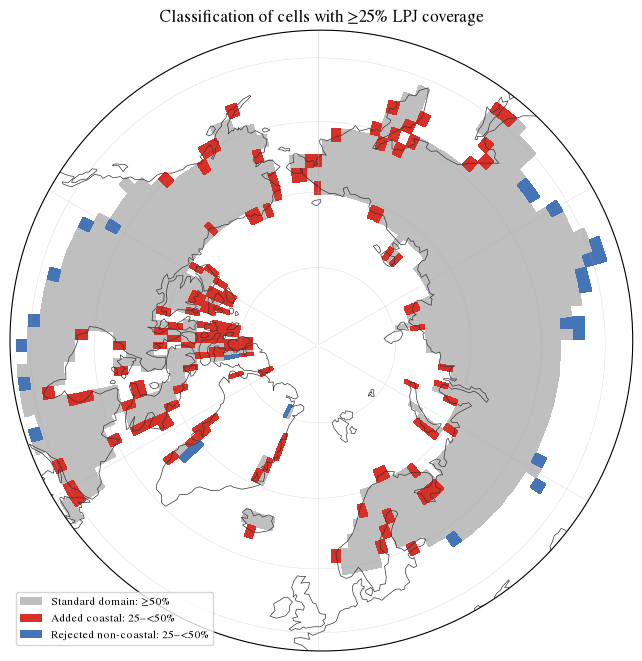

In [25]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(
    figsize=(6.5, 6.5),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
    layout="constrained",
)

ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
circular_boundary(ax)
ax.coastlines(resolution="110m", linewidth=0.5, color="0.2")
ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)

for field, color in [
    (standard_domain, "0.75"),
    (proposed_coastal_extension, "#D73027"),
    (rejected_low_coverage, "#4575B4"),
]:
    xr.where(field, 1.0, np.nan).plot.pcolormesh(
        ax=ax,
        x="lon",
        y="lat",
        transform=ccrs.PlateCarree(),
        cmap=mcolors.ListedColormap([color]),
        add_colorbar=False,
    )

ax.set_title("Classification of cells with ≥25% LPJ coverage")

ax.legend(
    handles=[
        Patch(facecolor="0.75", label="Standard domain: ≥50%"),
        Patch(facecolor="#D73027", label="Added coastal: 25–<50%"),
        Patch(facecolor="#4575B4", label="Rejected non-coastal: 25–<50%"),
    ],
    loc="lower left",
    fontsize=8,
    frameon=True,
)

plt.show()

,class,CLM cells,natural-vegetation area [km²],area share [%]
0,Standard ≥50%,876,20951946.0,85.5
1,Coastal 25–<50%,132,1572406.0,6.4
2,Coastal 10–<25%,97,791436.0,3.2
3,Non-coastal 25–<50%,25,674828.0,2.8
4,Non-coastal 10–<25%,25,521175.0,2.1


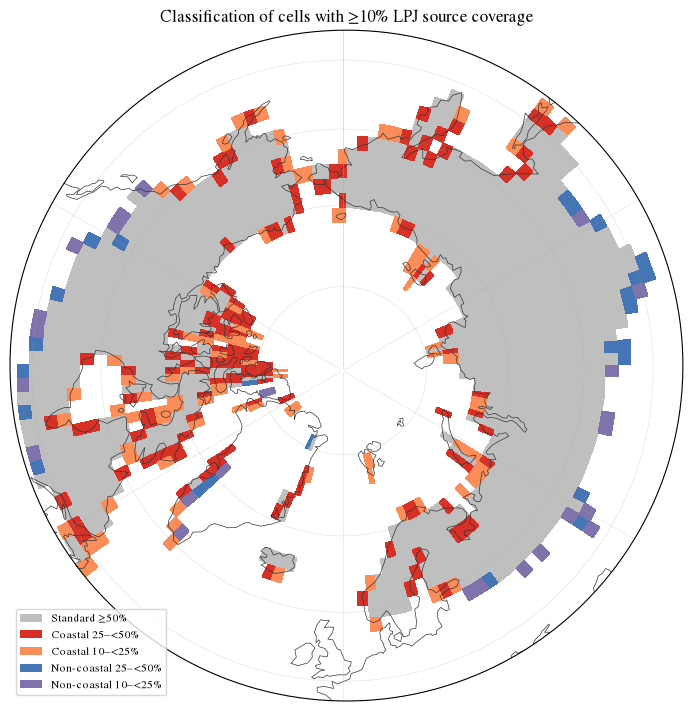

In [26]:
TEST_THRESHOLD = 0.10

standard_domain = coverage_domain & (source_coverage >= 0.50)

coverage_10_25 = (
    coverage_domain
    & (source_coverage >= TEST_THRESHOLD)
    & (source_coverage < 0.25)
)

coverage_25_50 = (
    coverage_domain
    & (source_coverage >= 0.25)
    & (source_coverage < 0.50)
)

classes = {
    "Standard ≥50%": standard_domain,
    "Coastal 25–<50%": coverage_25_50 & clm_coastal,
    "Coastal 10–<25%": coverage_10_25 & clm_coastal,
    "Non-coastal 25–<50%": coverage_25_50 & ~clm_coastal,
    "Non-coastal 10–<25%": coverage_10_25 & ~clm_coastal,
}

colors = {
    "Standard ≥50%": "0.75",
    "Coastal 25–<50%": "#D73027",
    "Coastal 10–<25%": "#FC8D59",
    "Non-coastal 25–<50%": "#4575B4",
    "Non-coastal 10–<25%": "#8073AC",
}

# Cell counts and natural-vegetation area
rows = []

for label, mask in classes.items():
    rows.append({
        "class": label,
        "CLM cells": int(mask.sum().item()),
        "natural-vegetation area [km²]":
            physical_weight.where(mask).sum(skipna=True).item() / 1e6,
    })

threshold_10_summary = pd.DataFrame(rows)
threshold_10_summary["area share [%]"] = (
    100
    * threshold_10_summary["natural-vegetation area [km²]"]
    / threshold_10_summary["natural-vegetation area [km²]"].sum()
)

display(threshold_10_summary.round({
    "natural-vegetation area [km²]": 0,
    "area share [%]": 1,
}))

# Map
fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
    layout="constrained",
)

ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
circular_boundary(ax)
ax.coastlines(resolution="110m", linewidth=0.5, color="0.2")
ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)

for label, mask in classes.items():
    xr.where(mask, 1.0, np.nan).plot.pcolormesh(
        ax=ax,
        x="lon",
        y="lat",
        transform=ccrs.PlateCarree(),
        cmap=mcolors.ListedColormap([colors[label]]),
        add_colorbar=False,
    )

ax.set_title("Classification of cells with ≥10% LPJ source coverage")

ax.legend(
    handles=[
        Patch(facecolor=colors[label], label=label)
        for label in classes
    ],
    loc="lower left",
    fontsize=8,
    frameon=True,
)

plt.show()

In [27]:
threshold_10_domain = (
    coverage_domain
    & (source_coverage >= TEST_THRESHOLD)
)

print("Cells retained at 10%:", int(threshold_10_domain.sum().item()))
print(
    "Natural-vegetation area retained at 10% [km²]:",
    round(
        physical_weight.where(threshold_10_domain)
        .sum(skipna=True).item() / 1e6
    ),
)

Cells retained at 10%: 1155
Natural-vegetation area retained at 10% [km²]: 24511791


In [38]:
COVERAGE_EPS = 1e-12

positive_coverage_domain = (
    coverage_domain
    & (source_coverage > COVERAGE_EPS)
)

coverage_classes = {
    ">0–<10%": (
        positive_coverage_domain
        & (source_coverage < 0.10)
    ),
    "10–<25%": (
        positive_coverage_domain
        & (source_coverage >= 0.10)
        & (source_coverage < 0.25)
    ),
    "25–<50%": (
        positive_coverage_domain
        & (source_coverage >= 0.25)
        & (source_coverage < 0.50)
    ),
    "≥50%": (
        positive_coverage_domain
        & (source_coverage >= 0.50)
    ),
}

coverage_colors = {
    ">0–<10%": "#762A83",
    "10–<25%": "#4575B4",
    "25–<50%": "#F46D43",
    "≥50%": "0.75",
}

# Counts and physical area
rows = []

for label, mask in coverage_classes.items():
    rows.append({
        "coverage class": label,
        "CLM cells": int(mask.sum().item()),
        "natural-vegetation area [km²]":
            physical_weight.where(mask).sum(skipna=True).item() / 1e6,
        "coastal cells": int((mask & clm_coastal).sum().item()),
        "non-coastal cells": int((mask & ~clm_coastal).sum().item()),
    })

positive_coverage_summary = pd.DataFrame(rows)
positive_coverage_summary["area share [%]"] = (
    100
    * positive_coverage_summary["natural-vegetation area [km²]"]
    / positive_coverage_summary["natural-vegetation area [km²]"].sum()
)

display(positive_coverage_summary.round({
    "natural-vegetation area [km²]": 0,
    "area share [%]": 1,
}))

positive_values = source_coverage.where(
    positive_coverage_domain
).values

positive_values = positive_values[np.isfinite(positive_values)]

print(f"Cells with positive coverage: {int(positive_coverage_domain.sum())}")
print(f"Minimum positive coverage: {positive_values.min():.3e}")
print(
    "Coverage percentiles:",
    dict(zip(
        [0, 1, 5, 25, 50],
        np.percentile(positive_values, [0, 1, 5, 25, 50]).round(6),
    )),
)

,coverage class,CLM cells,natural-vegetation area [km²],coastal cells,non-coastal cells,area share [%]
0,>0–<10%,154,1169906.0,122,32,4.6
1,10–<25%,122,1312611.0,97,25,5.1
2,25–<50%,157,2247234.0,132,25,8.8
3,≥50%,876,20951946.0,181,695,81.6


Cells with positive coverage: 1309
Minimum positive coverage: 4.458e-07
Coverage percentiles: {0: np.float64(0.0), 1: np.float64(0.00806), 5: np.float64(0.034173), 25: np.float64(0.336537), 50: np.float64(0.868269)}


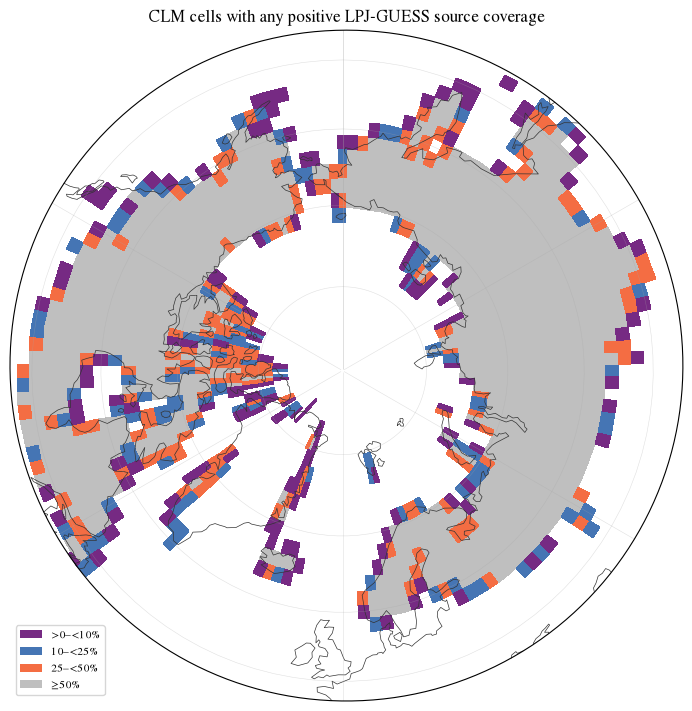

In [39]:
fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
    layout="constrained",
)

ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
circular_boundary(ax)
ax.coastlines(resolution="110m", linewidth=0.5, color="0.2")
ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)

# Plot high coverage first and the lowest coverage last,
# so small sliver-overlap cells remain visible.
for label in ["≥50%", "25–<50%", "10–<25%", ">0–<10%"]:
    mask = coverage_classes[label]

    xr.where(mask, 1.0, np.nan).plot.pcolormesh(
        ax=ax,
        x="lon",
        y="lat",
        transform=ccrs.PlateCarree(),
        cmap=mcolors.ListedColormap([coverage_colors[label]]),
        add_colorbar=False,
    )

ax.set_title("CLM cells with any positive LPJ-GUESS source coverage")

ax.legend(
    handles=[
        Patch(facecolor=coverage_colors[label], label=label)
        for label in coverage_classes
    ],
    loc="lower left",
    fontsize=8,
    frameon=True,
)

plt.show()

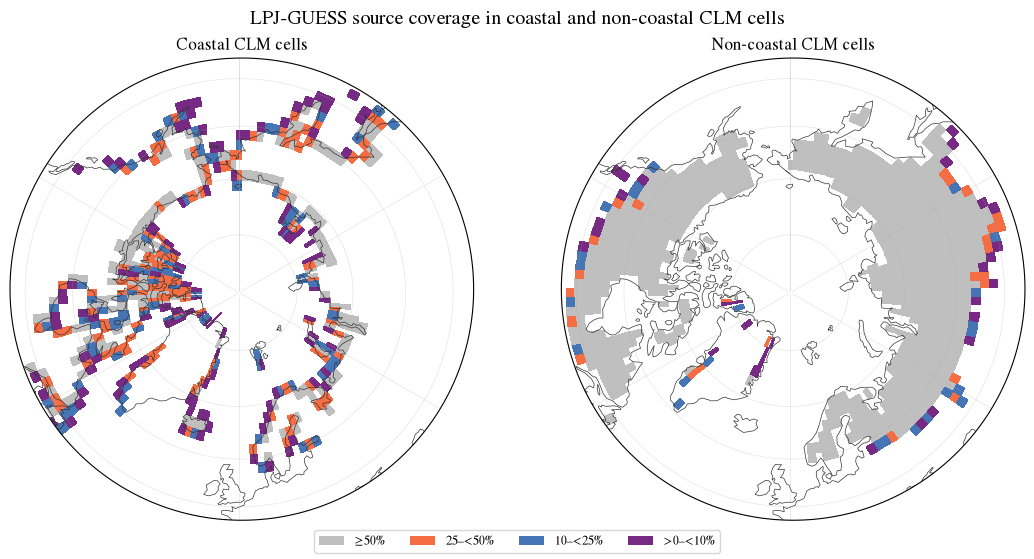

In [40]:
plot_order = ["≥50%", "25–<50%", "10–<25%", ">0–<10%"]

fig, axes = plt.subplots(
    1, 2, figsize=(11, 5.5),
    subplot_kw={"projection": ccrs.Orthographic(0, 90)},
    layout="constrained",
)

for ax in axes:
    ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
    circular_boundary(ax)
    ax.coastlines(resolution="110m", linewidth=0.5, color="0.2")
    ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)

domains = {
    "Coastal CLM cells": clm_coastal,
    "Non-coastal CLM cells": ~clm_coastal,
}

for ax, (title, domain_mask) in zip(axes, domains.items()):
    for label in plot_order:
        mask = coverage_classes[label] & domain_mask

        xr.where(mask, 1.0, np.nan).plot.pcolormesh(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=mcolors.ListedColormap([coverage_colors[label]]),
            add_colorbar=False,
        )

    ax.set_title(title)

fig.legend(
    handles=[
        Patch(facecolor=coverage_colors[label], label=label)
        for label in plot_order
    ],
    loc="outside lower center",
    ncols=4,
    fontsize=9,
    frameon=True,
)

fig.suptitle(
    "LPJ-GUESS source coverage in coastal and non-coastal CLM cells",
    fontsize=14,
)

plt.show()

## 10. Safely write and reopen the surface dataset

In [18]:
WRITE_OUTPUT = True

def sha256(path, chunk_size=1024**2):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def safe_encoding(dataset):
    allowed = {
        "zlib", "complevel", "shuffle", "fletcher32", "contiguous", "chunksizes",
        "dtype", "_FillValue", "endian", "least_significant_digit", "significant_digits",
    }
    return {
        name: {key: value for key, value in variable.encoding.items() if key in allowed}
        for name, variable in dataset.variables.items()
    }


if WRITE_OUTPUT:
    if SURF_OUT.exists() and not OVERWRITE:
        raise FileExistsError(f"Output exists; set OVERWRITE=True to replace it: {SURF_OUT}")

    pct_native = convert180_360(pct_new)
    original = surf_geo["PCT_NAT_PFT"]
    if not np.allclose(pct_native.lat, original.lat):
        raise ValueError("Latitude order does not match the input surfdata")
    if not np.allclose(pct_native.lon, original.lon):
        raise ValueError("Longitude order does not match the input surfdata")
    if not np.array_equal(pct_native.natpft, original.natpft):
        raise ValueError("Natural-PFT coordinate does not match the input surfdata")

    surf_out = surf.copy(deep=True)
    surf_out["PCT_NAT_PFT"] = xr.DataArray(
        pct_native.transpose("natpft", "lat", "lon").values,
        dims=surf["PCT_NAT_PFT"].dims, coords=surf["PCT_NAT_PFT"].coords,
        attrs=surf["PCT_NAT_PFT"].attrs,
    )
    xr.testing.assert_identical(surf_out.drop_vars("PCT_NAT_PFT"), surf.drop_vars("PCT_NAT_PFT"))

    provenance = {
        "method": "maximum-FPC anomaly; losses first; positive gains scaled only if infeasible",
        "historical_period": HIST_PERIOD, "future_period": FUT_PERIOD,
        "historical_file": FPC_HIST.name, "future_file": FPC_FUT.name,
        "mapping_file": MAPPING_CSV.name, "gridlist_file": GRIDLIST.name,
        "historical_sha256": sha256(FPC_HIST), "future_sha256": sha256(FPC_FUT),
        "mapping_sha256": sha256(MAPPING_CSV), "gridlist_sha256": sha256(GRIDLIST),
        "minimum_source_coverage": MIN_SOURCE_COVERAGE,
        "pft_mapping": CONVERSION_SCHEME,
        "cells_modified": int(modify_domain.sum()),
        "cells_loss_clipped": int(loss_clipped.sum()),
        "cells_gain_scaled": int(gain_scaled.sum()),
        "cells_zero_gain_capacity": int(zero_capacity.sum()),
    }
    surf_out.attrs.update({
        "title": "CLM surfdata with LPJ-GUESS maximum-FPC natural-PFT anomalies",
        "history": (
            f"{dt.date.today():%Y-%m-%d}: PCT_NAT_PFT modified using maximum-FPC anomaly "
            f"({FUT_PERIOD} minus {HIST_PERIOD}).\n" + surf.attrs.get("history", "")
        ),
        "comment": (
            "Only PCT_NAT_PFT changed. PCT_NATVEG and other land-unit fractions are fixed. "
            "LPJ FPC was not normalized as a ground-area partition."
        ),
        "lpjguess_to_clm_provenance": json.dumps(provenance, sort_keys=True),
    })

    SURF_OUT.parent.mkdir(parents=True, exist_ok=True)
    temporary = SURF_OUT.with_suffix(SURF_OUT.suffix + ".tmp")
    surf_out.to_netcdf(temporary, format="NETCDF4", encoding=safe_encoding(surf_out))
    with xr.open_dataset(temporary) as check:
        written = check["PCT_NAT_PFT"]
        assert not bool(written.isnull().any())
        assert float(np.abs(written.sum("natpft", skipna=False) - 100).max()) < 1e-6
        assert float(written.min()) >= -1e-8
        assert float(written.max()) <= 100 + 1e-8
    os.replace(temporary, SURF_OUT)
    print(f"Saved and reopened successfully: {SURF_OUT}")
else:
    print("WRITE_OUTPUT=False: diagnostics completed; no surface dataset was written.")

FileExistsError: Output exists; set OVERWRITE=True to replace it: /nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc

## Run checklist

Before setting `WRITE_OUTPUT = True`, inspect:

- the native and regridded anomaly maps;
- the coverage map and number of retained CLM cells;
- cells with clipped losses, scaled gains, or zero gain capacity;
- requested, realised, and adjustment maps;
- the residual bare-ground change and the final distribution;
- the output filename and period labels.

## Conclusion

### Input and spatial coverage

* Historical, future, and grid-list domains contain the same **16,750 LPJ-GUESS cells**.

* The anomaly is defined as:

  $$
  \Delta FPC_{\max}
  =
  FPC_{\max,\,2071-2100}
  -
  FPC_{\max,\,1971-2000}.
  $$

* Conservative regridding preserves the main spatial patterns on the coarser CLM grid.

* Of 1,309 CLM cells receiving a finite anomaly, **876 cells** satisfy the minimum 50% source-coverage threshold and are modified.

### Main vegetation signal

The Max-FPC anomaly indicates:

* expansion of boreal needleleaf evergreen trees;
* strong larch expansion, particularly across Siberia;
* widespread boreal broadleaf deciduous expansion;
* smaller and spatially mixed shrub changes;
* widespread decline in Arctic C3 grass.

### Effect of the CLM constraints

Among the 876 modified cells:

* **340 cells (38.8%)** contain at least one clipped PFT loss;
* **712 cells (81.3%)** require positive gains to be scaled;
* **14 cells (1.6%)** have no capacity for the requested gains.

The constraints therefore materially alter the LPJ-GUESS signal rather than acting only in a few exceptional cells.

### Area-weighted changes

| CLM PFT                       | Requested change | Realised change | Requested change realised |
| ----------------------------- | ---------------: | --------------: | ------------------------: |
| Boreal needleleaf evergreen   |         +4.07 pp |        +2.16 pp |                       53% |
| Larch                         |         +7.56 pp |        +3.64 pp |                       48% |
| Temperate broadleaf deciduous |         +0.90 pp |        +0.46 pp |                       51% |
| Boreal broadleaf deciduous    |         +8.27 pp |        +4.98 pp |                       60% |
| Boreal shrub                  |         +1.23 pp |        +0.64 pp |                       53% |
| Arctic C3 grass               |        −10.33 pp |        −8.87 pp |                       86% |

The mapped PFTs request a net increase of **11.70 percentage points**, but only **3.01 percentage points** can be accommodated. Natural bare ground consequently decreases by **3.01 percentage points**.

### Numerical validation

The final surface dataset satisfies the required constraints:

* all `PCT_NAT_PFT` values are non-negative;
* every valid natural-PFT column sums to 100%;
* the maximum closure residual is $9.95\times10^{-14}$;
* untouched PFTs remain unchanged;
* cells outside the modification domain remain unchanged.

### Interpretation

The result should be interpreted as a:

> **constrained, Max-FPC-informed redistribution of the existing CLM natural land unit**

It is not a direct conversion of LPJ-GUESS FPC into CLM ground-area fractions.

The bare-ground change is the residual required to close the CLM partition. It should not be interpreted as an independently simulated change in lichen, moss, or other nonvascular vegetation.

### Recommended sensitivity checks

Before production simulations:

1. compare source-coverage thresholds of 50%, 75%, and 90%;
2. inspect the requested, realised, and adjustment maps;
3. retain the constraint diagnostics alongside the surface dataset;
4. document that the feasibility constraints substantially reduce the requested tree expansion.
